# Structural network plots
## A computational investigation of compact graph summaries

A structural network plot is a bounded-size visual summary combining vertex distributions, community sizes and bottleneck indicators. This investigation distinguishes numerical correctness, retention of structural information, computational cost and human readability. The first three are investigated here. No participant responses or task-completion times are generated.

Five complete, small empirical or literary benchmark graphs provide interpretable case studies. Controlled graph ensembles extend the experiments to 10,000 vertices. The cases support inspection of individual relationships; generated graphs support controlled changes in size and structure. This does not establish performance on large empirical networks.

### Research questions
1. Which distributions and mesoscale descriptors distinguish graph structure without displaying every edge?
2. How can these quantities form a consistent, compact plot, and what information is omitted?
3. How does the representation compare with node-link and adjacency-matrix views in computational cost and structural discrimination?

In [1]:
from pathlib import Path
import sys, json, time, platform, hashlib, warnings, itertools, math, tracemalloc, gzip
import numpy as np
import pandas as pd
import scipy
from scipy.stats import spearmanr
import networkx as nx
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, adjusted_rand_score
from sklearn.inspection import permutation_importance
import sklearn
ROOT=Path.cwd()
if not (ROOT/'data'/'datasets.json').exists():
    raise FileNotFoundError('Open the notebook from the extracted structural_network_plots directory.')
OUT=ROOT/'results'; FIG=ROOT/'figures'; OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
SEED=20260906
np.random.seed(SEED)
plt.rcParams.update({'font.size':10,'axes.titlesize':12,'axes.labelsize':10,'figure.dpi':110,'savefig.dpi':180})
figures=[]
versions={'Python':sys.version.split()[0], 'NetworkX':nx.__version__, 'NumPy':np.__version__, 'pandas':pd.__version__, 'SciPy':scipy.__version__, 'Matplotlib':matplotlib.__version__, 'scikit-learn':sklearn.__version__, 'platform':platform.platform(), 'seed':SEED}
(OUT/'environment.json').write_text(json.dumps(versions,indent=2))
display(pd.DataFrame(list(versions.items()),columns=['Component','Version or setting']))

,Component,Version or setting
0,Python,3.13.5
1,NetworkX,3.6.1
2,NumPy,2.3.5
3,pandas,2.2.3
4,SciPy,1.17.0
5,Matplotlib,3.10.8
6,scikit-learn,1.8.0
7,platform,Linux-6.18.35-x86_64-with-glibc2.41
8,seed,20260906


In [2]:
def save_table(name, frame):
    frame.to_csv(OUT/f'{name}.csv',index=False)
    return frame

def show_figure(name, title, description):
    fig=plt.gcf(); fig.tight_layout()
    path=FIG/f'{len(figures)+1:02d}_{name}.png'; fig.savefig(path,bbox_inches='tight')
    figures.append({'number':len(figures)+1,'file':path.name,'title':title,'description':description})
    (OUT/'figure_register.json').write_text(json.dumps(figures,indent=2))
    plt.show(); plt.close(fig)

def gini(values):
    x=np.sort(np.asarray(values,dtype=float)); n=len(x)
    return float(2*np.sum((np.arange(n)+1)*x)/(n*x.sum())-(n+1)/n) if n and x.sum()>0 else 0.0

def canonical_graph(raw):
    labels=sorted(raw.nodes,key=lambda x:(type(x).__name__,repr(x)))
    mapping={v:i for i,v in enumerate(labels)}
    g=nx.Graph(); g.add_nodes_from(range(len(labels)))
    loops=0; collapsed=0
    for u,v in raw.edges():
        if u==v: loops+=1; continue
        a,b=sorted((mapping[u],mapping[v]))
        if g.has_edge(a,b): collapsed+=1
        g.add_edge(a,b)
    return g,mapping,{'input_nodes':len(raw),'input_edges':raw.number_of_edges(),'removed_loops':loops,'collapsed_pairs':collapsed,'analysis_nodes':len(g),'analysis_edges':g.number_of_edges()}

def describe_graph(g,seed=SEED,sample=32,resolution=1.0,include_betweenness=True):
    n=len(g); m=g.number_of_edges(); nodes=list(g)
    degree=np.array([g.degree(v) for v in nodes],dtype=float)
    clustering=np.array(list(nx.clustering(g).values()),dtype=float) if n else np.array([])
    core_d=nx.core_number(g) if n else {}; core=np.array([core_d[v] for v in nodes],dtype=float)
    components=list(nx.connected_components(g)); bridges=list(nx.bridges(g)); articulation=list(nx.articulation_points(g))
    if m:
        communities=nx.community.louvain_communities(g,weight=None,resolution=resolution,seed=seed)
        communities=sorted(communities,key=lambda c:(-len(c),min(c)))
        modularity=nx.community.modularity(g,communities,weight=None,resolution=resolution)
    else: communities=[{v} for v in nodes]; modularity=0.0
    if include_betweenness and n:
        bw=nx.betweenness_centrality(g,k=min(sample,n),normalized=True,weight=None,seed=seed)
        between=np.array([bw[v] for v in nodes])
    else: between=np.zeros(n)
    k1=[]; k2=[]
    for u,v in g.edges(): k1.extend([g.degree(u),g.degree(v)]); k2.extend([g.degree(v),g.degree(u)])
    assort=float(np.corrcoef(k1,k2)[0,1]) if k1 and np.std(k1)>0 and np.std(k2)>0 else np.nan
    q=lambda x,p:float(np.quantile(x,p)) if len(x) else 0.0
    sizes=np.array([len(c) for c in communities],dtype=float)
    d={'n':n,'m':m,'density':nx.density(g),'mean_degree':float(degree.mean()) if n else 0.0,'degree_cv':float(degree.std()/degree.mean()) if m else 0.0,'degree_gini':gini(degree),'degree_q25':q(degree,.25),'degree_q50':q(degree,.5),'degree_q75':q(degree,.75),'degree_q95':q(degree,.95),'clustering_mean':float(clustering.mean()) if n else 0.0,'clustering_q25':q(clustering,.25),'clustering_q50':q(clustering,.5),'clustering_q75':q(clustering,.75),'transitivity':nx.transitivity(g),'triangles':sum(nx.triangles(g).values())//3 if n else 0,'components':len(components),'largest_component_fraction':max(map(len,components),default=0)/max(n,1),'isolate_fraction':sum(degree==0)/max(n,1),'bridges':len(bridges),'bridge_fraction':len(bridges)/max(m,1),'articulation_fraction':len(articulation)/max(n,1),'core_max':float(core.max()) if n else 0.0,'core_mean':float(core.mean()) if n else 0.0,'communities':len(communities),'modularity':float(modularity),'largest_community_fraction':sizes.max()/max(n,1) if len(sizes) else 0.0,'community_gini':gini(sizes),'assortativity':assort,'betweenness_mean':float(between.mean()) if n else 0.0,'betweenness_q95':q(between,.95)}
    return d,{'degree':degree,'clustering':clustering,'core':core,'betweenness':between,'communities':communities,'bridges':bridges,'articulations':articulation}
print('Canonicalisation, descriptor extraction, table export and figure export functions are defined.')

Canonicalisation, descriptor extraction, table export and figure export functions are defined.


## 1. Data and graph semantics

Four source graphs are distributed with NetworkX 3.6.1. An archival C. elegans neural graph is distributed with igraph and retained in its original compressed Graph Modelling Language (GML) file. Its header dates that export to 31 August 2006; it is not a contemporary complete connectome. The karate-club graph records a social network; its integer weights represent interaction contexts. Les Misérables is a literary co-occurrence graph, not a sampled population. Southern women is bipartite, linking women to events. Florentine families is a historical marriage network. The C. elegans archive is directed and contains repeated ordered pairs with a value attribute. The parser enables multigraph semantics in memory, preserving all 2,359 records rather than rejecting or discarding duplicates. Raw attributes are retained. The common analysis uses simple, undirected, unweighted graphs; weighted and bipartite transformations are evaluated separately rather than treated as equivalent. The first four distributions credit Zachary (1977), Knuth (1993), Davis, Gardner and Gardner (1941), and Breiger and Pattison (1986), respectively. These are archival source credits, not contemporary observations. No missing edges are imputed. All vertices, including isolates, are retained.

In [3]:
data_manifest=json.loads((ROOT/'data'/'datasets.json').read_text())
raw_graphs={}; graphs={}; maps={}; clean_rows=[]; empirical={}; details={}
for record in data_manifest:
    name=record['name']; p=ROOT/'data'/record['file']
    if p.suffix=='.gz':
        raw_bytes=p.read_bytes(); blob=hashlib.sha1(b'blob '+str(len(raw_bytes)).encode()+bytes([0])+raw_bytes).hexdigest()
        assert blob==record['git_blob'], 'The archived GML bytes do not match the source blob.'
        text=gzip.decompress(raw_bytes).decode('ascii'); text=text.replace('directed 1','directed 1 multigraph 1',1)
        raw_graphs[name]=nx.parse_gml(text)
    else:
        raw_graphs[name]=nx.node_link_graph(json.loads(p.read_text()))
    graphs[name],maps[name],counts=canonical_graph(raw_graphs[name])
    counts.update(dataset=name,sha256=hashlib.sha256(p.read_bytes()).hexdigest()); clean_rows.append(counts)
    empirical[name],details[name]=describe_graph(graphs[name])
cleaning=save_table('data_cleaning',pd.DataFrame(clean_rows))
corpus=save_table('empirical_descriptors',pd.DataFrame(empirical).T.rename_axis('dataset').reset_index())
display(cleaning.drop(columns='sha256'))
display(corpus[['dataset','n','m','density','components','triangles','bridges','modularity']].round(4))

,input_nodes,input_edges,removed_loops,collapsed_pairs,analysis_nodes,analysis_edges,dataset
0,34,78,0,0,34,78,Karate club
1,77,254,0,0,77,254,Les Miserables
2,32,89,0,0,32,89,Southern women
3,15,20,0,0,15,20,Florentine families
4,297,2359,0,211,297,2148,C. elegans


,dataset,n,m,density,components,triangles,bridges,modularity
0,Karate club,34.0,78.0,0.1390,1.0,45.0,1.0,0.4188
1,Les Miserables,77.0,254.0,0.0868,1.0,467.0,18.0,0.5591
2,Southern women,32.0,89.0,0.1794,1.0,0.0,0.0,0.3225
3,Florentine families,15.0,20.0,0.1905,1.0,3.0,5.0,0.3975
4,C. elegans,297.0,2148.0,0.0489,1.0,3241.0,15.0,0.3960


In [4]:
node_rows=[]; community_rows=[]; edge_rows=[]
for name,g in graphs.items():
    z=details[name]; membership={v:j for j,c in enumerate(z['communities']) for v in c}
    reverse={v:str(u) for u,v in maps[name].items()}
    bridge_set={frozenset(e) for e in z['bridges']}; articulation_set=set(z['articulations'])
    for i,v in enumerate(g):
        node_rows.append({'dataset':name,'vertex':v,'source_label':reverse[v],
            'degree':z['degree'][i],'clustering':z['clustering'][i],'core':z['core'][i],
            'betweenness':z['betweenness'][i],'community':membership[v],
            'articulation':v in articulation_set,'isolate':g.degree(v)==0})
    for j,c in enumerate(z['communities']):
        community_rows.append({'dataset':name,'community':j,'vertices':len(c),
            'vertex_share':len(c)/len(g),'internal_edges':g.subgraph(c).number_of_edges(),
            'internal_density':nx.density(g.subgraph(c))})
    for u,v in g.edges():
        edge_rows.append({'dataset':name,'source':u,'target':v,
            'bridge':frozenset((u,v)) in bridge_set,'within_community':membership[u]==membership[v]})
node_table=save_table('node_descriptors',pd.DataFrame(node_rows))
community_table=save_table('community_descriptors',pd.DataFrame(community_rows))
edge_table=save_table('edge_descriptors',pd.DataFrame(edge_rows))
assert len(node_table)==sum(map(len,graphs.values()))
assert len(edge_table)==sum(g.number_of_edges() for g in graphs.values())
assert node_table.groupby('dataset').degree.sum().equals(2*edge_table.groupby('dataset').size().astype(float))
display(pd.DataFrame({'table':['Vertices','Communities','Edges'],'rows':[len(node_table),len(community_table),len(edge_table)]}))
display(node_table.head().round(4))

,table,rows
0,Vertices,455
1,Communities,23
2,Edges,2589


,dataset,vertex,source_label,degree,clustering,core,betweenness,community,articulation,isolate
0,Karate club,0,0,16.0,0.1500,4.0,0.4469,0,True,False
1,Karate club,1,1,9.0,0.3333,4.0,0.0564,0,False,False
2,Karate club,2,10,3.0,0.6667,3.0,0.0007,3,False,False
3,Karate club,3,11,1.0,0.0000,1.0,0.0000,0,False,False
4,Karate club,4,12,2.0,1.0000,2.0,0.0000,0,False,False


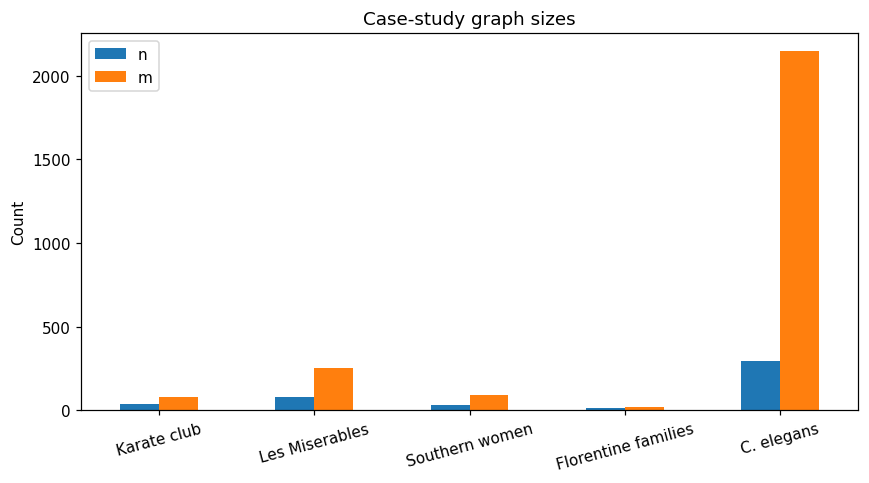

In [5]:
ax=corpus.set_index('dataset')[['n','m']].plot.bar(figsize=(8,4.5))
ax.set_ylabel('Count'); ax.set_xlabel(''); ax.tick_params(axis='x',rotation=15); ax.set_title('Case-study graph sizes')
show_figure('corpus_sizes','Case-study graph sizes','Complete source graphs; vertex and edge counts are not samples.')

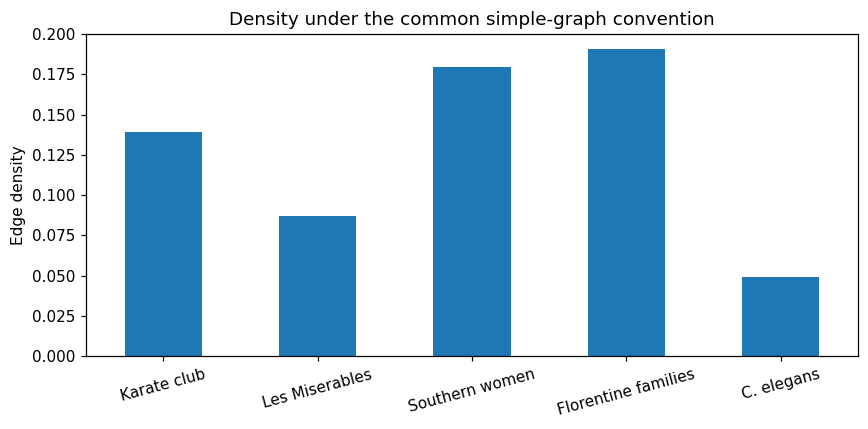

In [6]:
ax=corpus.set_index('dataset')['density'].plot.bar(figsize=(8,4))
ax.set_ylabel('Edge density'); ax.set_xlabel(''); ax.tick_params(axis='x',rotation=15); ax.set_title('Density under the common simple-graph convention')
show_figure('corpus_density','Case-study densities','Density uses the simple undirected convention, not the bipartite fill denominator.')

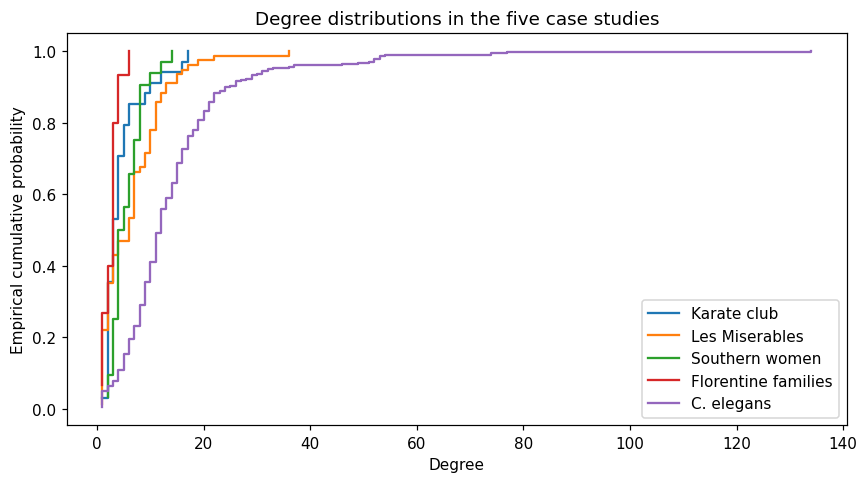

In [7]:
fig,ax=plt.subplots(figsize=(8,4.5))
for name,det in details.items():
    x=np.sort(det['degree']); ax.step(x,np.arange(1,len(x)+1)/len(x),where='post',label=name)
ax.set(xlabel='Degree',ylabel='Empirical cumulative probability',title='Degree distributions in the five case studies'); ax.legend()
show_figure('degree_ecdf','Degree distributions','Complete distributions are shown rather than only their means.')

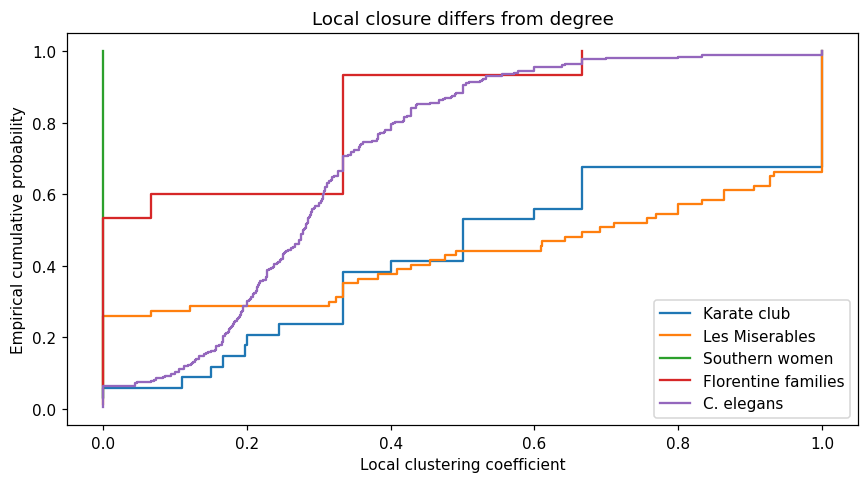

In [8]:
fig,ax=plt.subplots(figsize=(8,4.5))
for name,det in details.items():
    x=np.sort(det['clustering']); ax.step(x,np.arange(1,len(x)+1)/len(x),where='post',label=name)
ax.set(xlabel='Local clustering coefficient',ylabel='Empirical cumulative probability',title='Local closure differs from degree'); ax.legend()
show_figure('clustering_ecdf','Local clustering distributions','A bipartite graph has no triangles; zero clustering does not imply an absence of event structure.')

## 2. Numerical definitions and independent checks

Degree counts neighbours. Density is $2m/[n(n-1)]$. Local clustering is the fraction of neighbour pairs joined by an edge; vertices of degree below two receive zero. A bridge is an edge whose removal increases connected-component count; an articulation vertex has the corresponding vertex-removal property. Triangle counts indicate three-cycle frequency, not statistically enriched motifs.

Louvain communities are heuristic modularity partitions, not observed truth. Betweenness is the fraction of shortest paths passing through a vertex, estimated from up to 32 source vertices and checked against exact calculation later. Closed-form and direct removal tests below stop execution on failure. They address correctness, not readability.

Definitions follow the versioned NetworkX documentation (NetworkX Developers, 2025). Exact examples are used as independent checks, rather than accepting library agreement as sufficient evidence.

In [9]:
test_rows=[]
for n in [4,8,16,32]:
    specs=[('complete',nx.complete_graph(n),n*(n-1)//2,math.comb(n,3),0,1.0),('path',nx.path_graph(n),n-1,0,n-1,0.0),('cycle',nx.cycle_graph(n),n,0,0,0.0),('star',nx.star_graph(n-1),n-1,0,n-1,0.0)]
    for family,g,edges,tri,bridges,closure in specs:
        d,_=describe_graph(g)
        for metric,expected in [('m',edges),('triangles',tri),('bridges',bridges),('clustering_mean',closure)]:
            error=abs(d[metric]-expected); assert error<1e-12,(family,n,metric,error)
            test_rows.append(dict(test='closed_form',family=family,n=n,metric=metric,error=error,passed=True))
        assert sum(dict(g.degree()).values())==2*g.number_of_edges()
for n in range(2,9):
    for seed in range(4):
        g=nx.gnp_random_graph(n,.3,seed=seed); before=nx.number_connected_components(g); expected=set()
        for edge in list(g.edges()):
            h=g.copy(); h.remove_edge(*edge)
            if nx.number_connected_components(h)>before: expected.add(tuple(sorted(edge)))
        assert {tuple(sorted(e)) for e in nx.bridges(g)}==expected
        test_rows.append(dict(test='edge_removal_oracle',family='random',n=n,metric='bridges',error=0,passed=True))
for g in [nx.Graph(),nx.empty_graph(1),nx.empty_graph(5),nx.disjoint_union(nx.path_graph(4),nx.complete_graph(3))]:
    d,_=describe_graph(g); assert d['n']==len(g); assert np.isfinite(d['modularity'])
    test_rows.append(dict(test='boundary_case',family='empty_or_disconnected',n=len(g),metric='finite_output',error=0,passed=True))
g=nx.gnp_random_graph(30,.13,seed=SEED); h=nx.relabel_nodes(g,{v:29-v for v in g})
a,_=describe_graph(g,sample=30); b,_=describe_graph(h,sample=30)
for metric in ['n','m','triangles','bridges','clustering_mean','core_max','betweenness_mean']:
    assert np.isclose(a[metric],b[metric]); test_rows.append(dict(test='relabel_invariance',family='random',n=30,metric=metric,error=abs(a[metric]-b[metric]),passed=True))
tests=save_table('numerical_tests',pd.DataFrame(test_rows)); display(tests.groupby('test').agg(checks=('passed','size'),passed=('passed','sum'),maximum_error=('error','max')))

,checks,passed,maximum_error
test,,,
boundary_case,4,4,0.0
closed_form,64,64,0.0
edge_removal_oracle,28,28,0.0
relabel_invariance,7,7,0.0


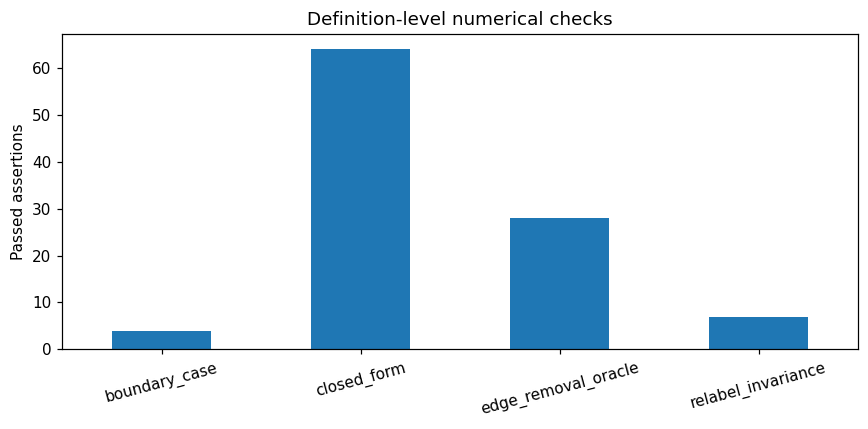

In [10]:
ax=tests.groupby('test')['passed'].sum().plot.bar(figsize=(8,4)); ax.set(xlabel='',ylabel='Passed assertions',title='Definition-level numerical checks'); ax.tick_params(axis='x',rotation=15)
show_figure('numerical_checks','Numerical verification coverage','Counts come from executed assertions; a passing test is not a usability result.')

## 3. The structural network plot

Four tracks show the 5th, 25th, 50th, 75th and 95th percentiles of degree, clustering, core number and sampled betweenness. Thin intervals span the 5th to 95th percentiles, thick intervals the interquartile range, and points mark medians. Degree and core use $\log(1+x)/\log(n)$ to accommodate skew. This transformation is size-dependent, so absolute medians also appear in the labels. Clustering and normalised betweenness lie in [0,1].

Community-block width represents vertex share. The twelve largest communities are displayed, followed by a residual block when needed. Block labels give internal density, not confidence. Three additional tracks give bridge-edge, articulation-vertex and isolate-vertex fractions. The summary omits edge identity, most tail detail, community adjacency and shortest-path routes.

The fixed measurement grammar differs from a small synthetic representative graph such as SynGraphy (Kunegis et al., 2023): no newly constructed edge is presented as if it were observed.

In [11]:
def structural_plot(g,name,seed=SEED,resolution=1.0):
    d,z=describe_graph(g,seed=seed,resolution=resolution); n=len(g)
    fig,ax=plt.subplots(figsize=(9,5.6)); labels=[]
    for y,key,label in [(7,'degree','Degree'),(6,'clustering','Local clustering'),(5,'core','Core number'),(4,'betweenness','Sampled betweenness')]:
        x=z[key]; qs=np.quantile(x,[.05,.25,.5,.75,.95]) if len(x) else np.zeros(5)
        pos=np.log1p(qs)/np.log(max(n,2)) if key in ['degree','core'] else qs
        ax.plot([pos[0],pos[4]],[y,y],linewidth=1.2); ax.plot([pos[1],pos[3]],[y,y],linewidth=6,solid_capstyle='butt'); ax.scatter(pos[2],y,marker='o',s=38)
        labels.append((y,f'{label} (median {qs[2]:.3g})'))
    groups=z['communities']; visible=groups[:12]
    if len(groups)>12: visible=visible+[set().union(*groups[12:])]
    left=0
    for j,c in enumerate(visible):
        width=len(c)/max(n,1); dens=nx.density(g.subgraph(c)); ax.add_patch(Rectangle((left,2.65),width,.7,fill=False,hatch='/' if j%2 else None,linewidth=1))
        if width>.075: ax.text(left+width/2,3,('Other' if j==12 else f'{dens:.2f}'),ha='center',va='center',fontsize=8)
        left+=width
    labels.append((3,'Community share (labels: density)'))
    for y,key,label in [(2,'bridge_fraction','Bridges / edges'),(1,'articulation_fraction','Articulations / vertices'),(0,'isolate_fraction','Isolates / vertices')]:
        ax.plot([0,d[key]],[y,y],linewidth=3); ax.scatter(d[key],y,marker='D',s=25); ax.text(min(d[key]+.025,.96),y+.13,f'{d[key]:.3f}',fontsize=8); labels.append((y,label))
    ax.set_yticks([x[0] for x in labels],[x[1] for x in labels]); ax.set_xlim(-.015,1.02); ax.set_ylim(-.5,7.6); ax.set_xlabel('Transformed value or fraction, as defined for each track')
    ax.set_title(f'{name}\nn={d["n"]:,}; m={d["m"]:,}; density={d["density"]:.3f}; Q={d["modularity"]:.3f}; communities={d["communities"]}',pad=14)
    return d
print('Four percentile tracks, one community strip and three bottleneck tracks are implemented.')

Four percentile tracks, one community strip and three bottleneck tracks are implemented.


,vertex,degree,clustering,core,exact_betweenness
0,0,2.0,1.000000,2.0,0.000000
1,1,2.0,1.000000,2.0,0.000000
2,2,3.0,0.333333,2.0,0.400000
3,3,2.0,0.000000,1.0,0.400000
4,4,2.0,0.000000,1.0,0.266667
5,5,1.0,0.000000,1.0,0.000000
6,6,0.0,0.000000,0.0,0.000000


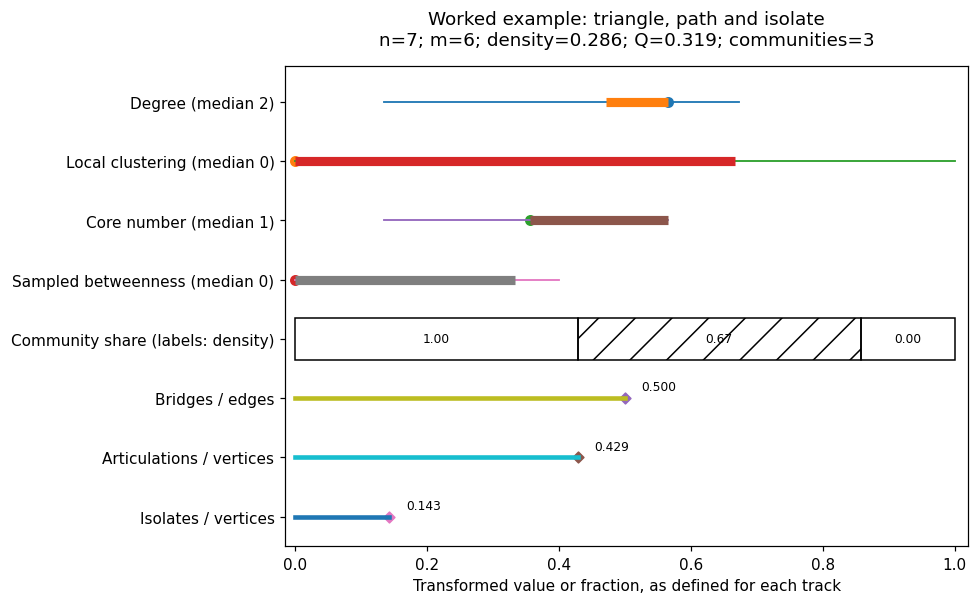

In [12]:
worked=nx.Graph(); worked.add_nodes_from(range(7)); worked.add_edges_from([(0,1),(1,2),(2,0),(2,3),(3,4),(4,5)])
wd,wz=describe_graph(worked,sample=7)
assert wd['n']==7 and wd['m']==6 and wd['triangles']==1 and wd['bridges']==3 and np.isclose(wd['clustering_mean'],1/3)
display(save_table('worked_example',pd.DataFrame({'vertex':list(worked),'degree':wz['degree'],'clustering':wz['clustering'],'core':wz['core'],'exact_betweenness':wz['betweenness']})))
structural_plot(worked,'Worked example: triangle, path and isolate')
show_figure('worked_example','A worked structural network plot','Seven vertices, six edges, one triangle, three bridges and one isolate.')

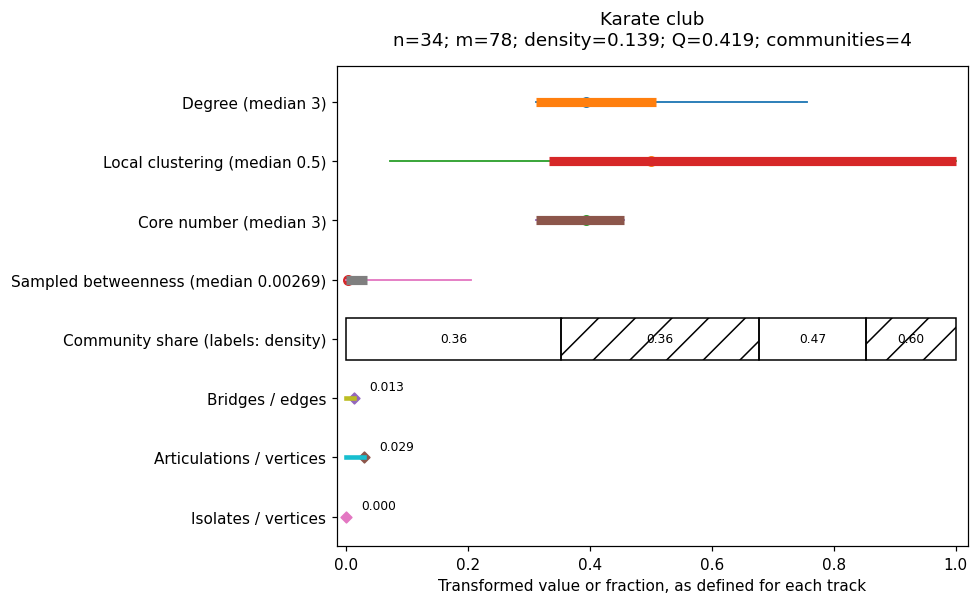

In [13]:
structural_plot(graphs['Karate club'],'Karate club')
show_figure('snp_karate','Structural plot: Karate club','The same grammar and percentile definitions are used for every graph.')

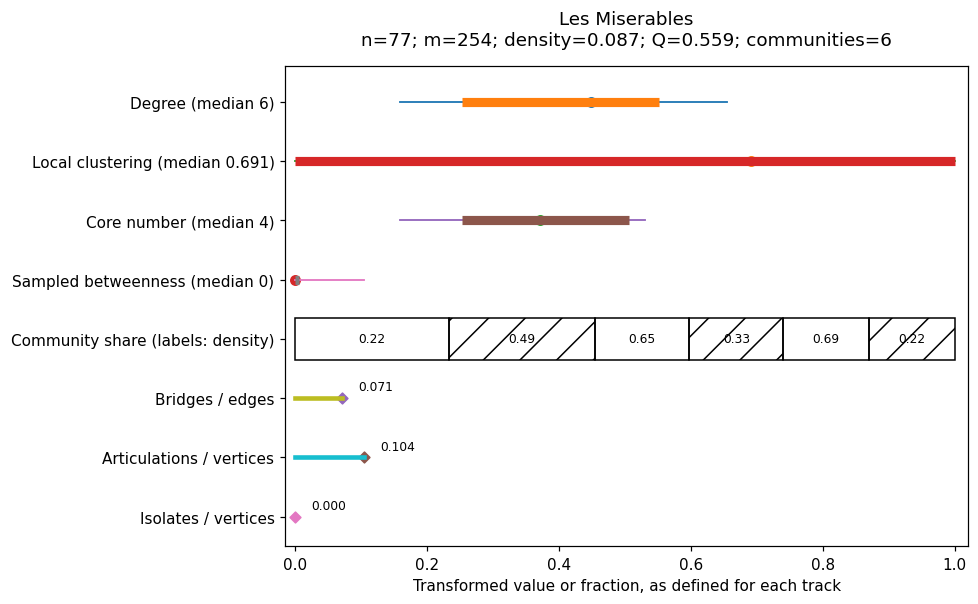

In [14]:
structural_plot(graphs['Les Miserables'],'Les Miserables')
show_figure('snp_lesmis','Structural plot: Les Miserables','The same grammar and percentile definitions are used for every graph.')

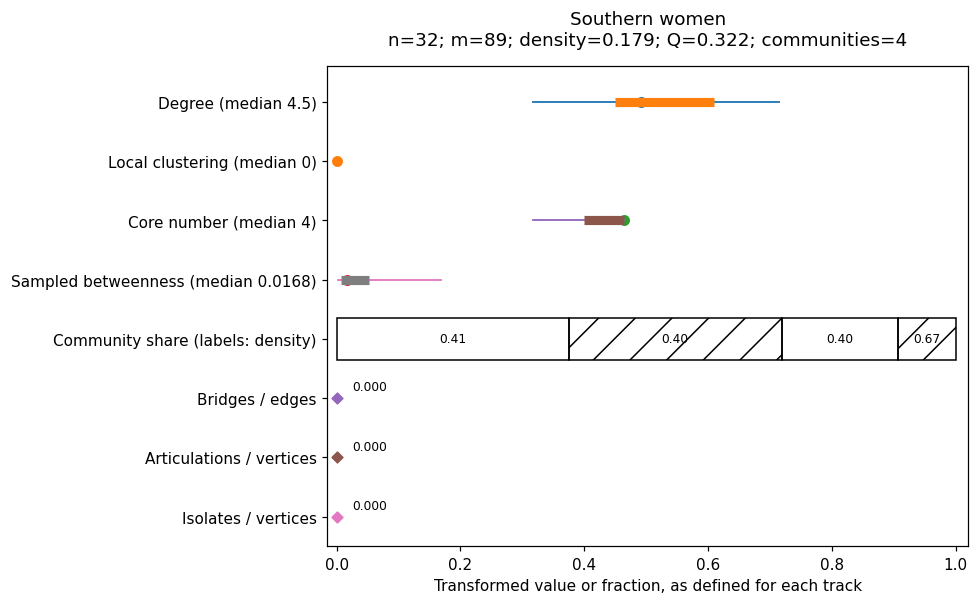

In [15]:
structural_plot(graphs['Southern women'],'Southern women')
show_figure('snp_davis','Structural plot: Southern women','The same grammar and percentile definitions are used for every graph.')

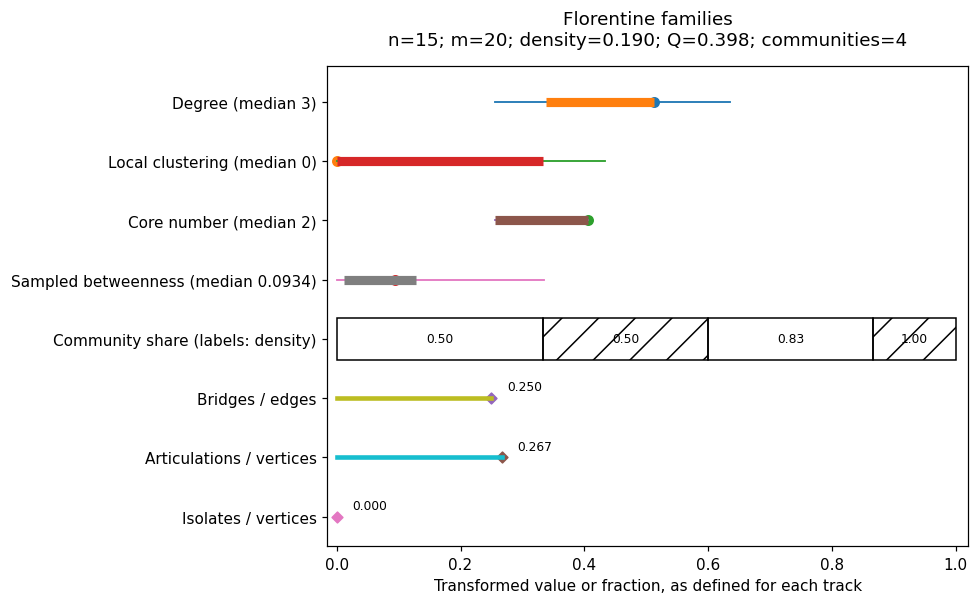

In [16]:
structural_plot(graphs['Florentine families'],'Florentine families')
show_figure('snp_florentine','Structural plot: Florentine families','The same grammar and percentile definitions are used for every graph.')

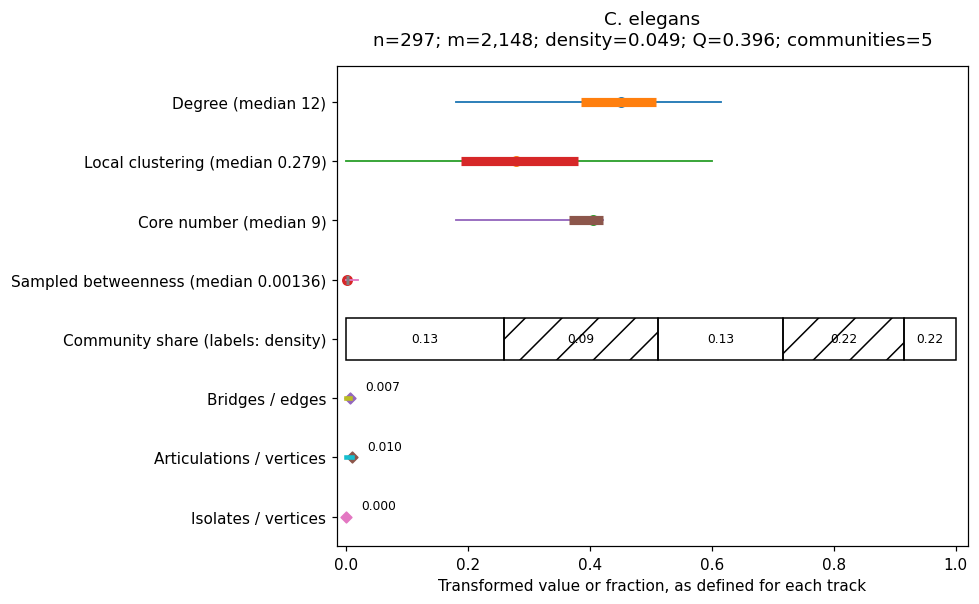

In [17]:
structural_plot(graphs['C. elegans'],'C. elegans')
show_figure('snp_celegans','Structural plot: C. elegans','The same grammar and percentile definitions are used for every graph.')

## 4. Baseline views and empirical interpretation

Node-link views expose relationships that the summary omits. Adjacency matrices retain pairwise edges but require an ordering. Here that order follows detected communities, then degree within each community. All views contain the complete graph. Neither baseline is evaluated through simulated human answers.

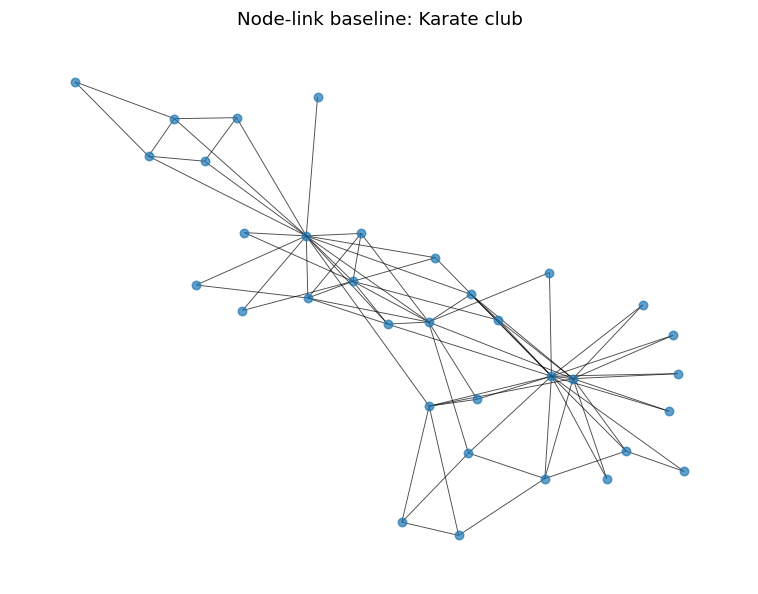

In [18]:
g=graphs['Karate club']; fig,ax=plt.subplots(figsize=(7,5.5)); pos=nx.spring_layout(g,seed=SEED,iterations=100,weight=None,method='force')
nx.draw_networkx(g,pos=pos,ax=ax,node_size=30,with_labels=False,width=.6,alpha=.7); ax.set_title('Node-link baseline: Karate club'); ax.set_axis_off()
show_figure('node_link_karate','Node-link baseline: Karate club','Complete graph; a 100-iteration force-directed layout uses a fixed seed.')

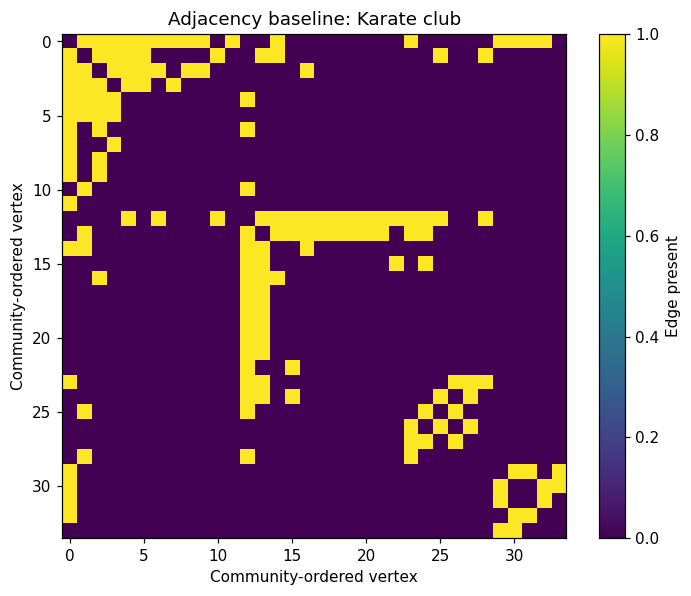

In [19]:
g=graphs['Karate club']; communities=details['Karate club']['communities']; order=[v for c in communities for v in sorted(c,key=lambda v:(-g.degree(v),v))]
A=nx.to_numpy_array(g,nodelist=order,weight=None); fig,ax=plt.subplots(figsize=(6.8,5.5)); im=ax.imshow(A,interpolation='nearest'); ax.set(xlabel='Community-ordered vertex',ylabel='Community-ordered vertex',title='Adjacency baseline: Karate club'); fig.colorbar(im,ax=ax,label='Edge present')
show_figure('matrix_karate','Adjacency-matrix baseline: Karate club','Ordering uses the same inferred partition as the summary, not external labels.')

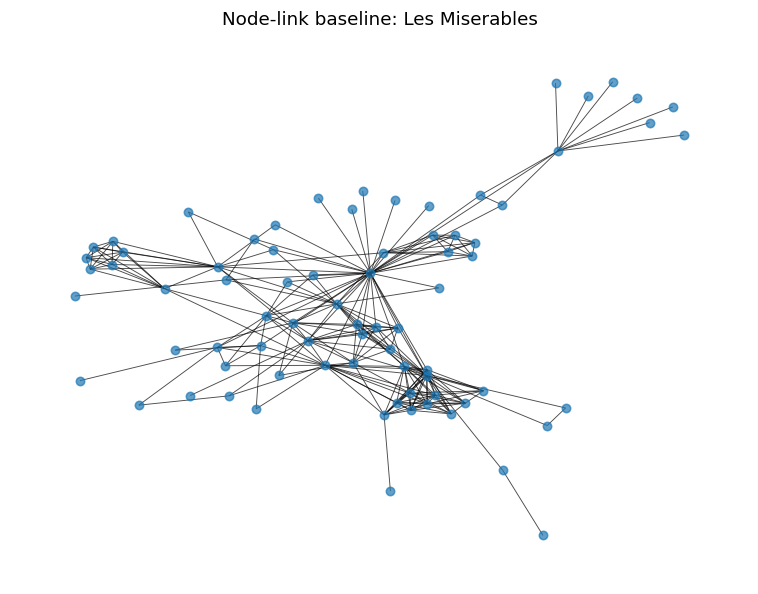

In [20]:
g=graphs['Les Miserables']; fig,ax=plt.subplots(figsize=(7,5.5)); pos=nx.spring_layout(g,seed=SEED,iterations=100,weight=None,method='force')
nx.draw_networkx(g,pos=pos,ax=ax,node_size=30,with_labels=False,width=.6,alpha=.7); ax.set_title('Node-link baseline: Les Miserables'); ax.set_axis_off()
show_figure('node_link_lesmis','Node-link baseline: Les Miserables','Complete graph; a 100-iteration force-directed layout uses a fixed seed.')

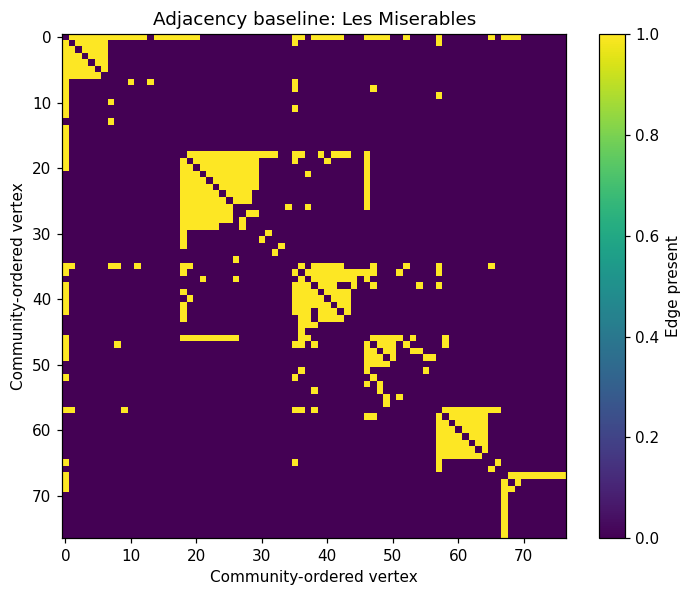

In [21]:
g=graphs['Les Miserables']; communities=details['Les Miserables']['communities']; order=[v for c in communities for v in sorted(c,key=lambda v:(-g.degree(v),v))]
A=nx.to_numpy_array(g,nodelist=order,weight=None); fig,ax=plt.subplots(figsize=(6.8,5.5)); im=ax.imshow(A,interpolation='nearest'); ax.set(xlabel='Community-ordered vertex',ylabel='Community-ordered vertex',title='Adjacency baseline: Les Miserables'); fig.colorbar(im,ax=ax,label='Edge present')
show_figure('matrix_lesmis','Adjacency-matrix baseline: Les Miserables','Ordering uses the same inferred partition as the summary, not external labels.')

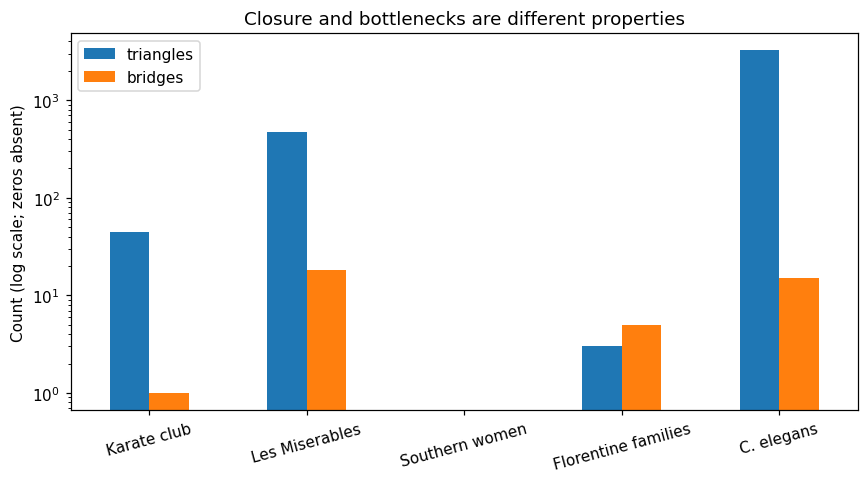

In [22]:
ax=corpus.set_index('dataset')[['triangles','bridges']].plot.bar(figsize=(8,4.5),logy=True); ax.set_ylabel('Count (log scale; zeros absent)'); ax.set_xlabel(''); ax.tick_params(axis='x',rotation=15); ax.set_title('Closure and bottlenecks are different properties')
show_figure('triangles_bridges','Triangles and bridges','Zero bars are absent on the logarithmic axis and remain explicit in the descriptor table.')

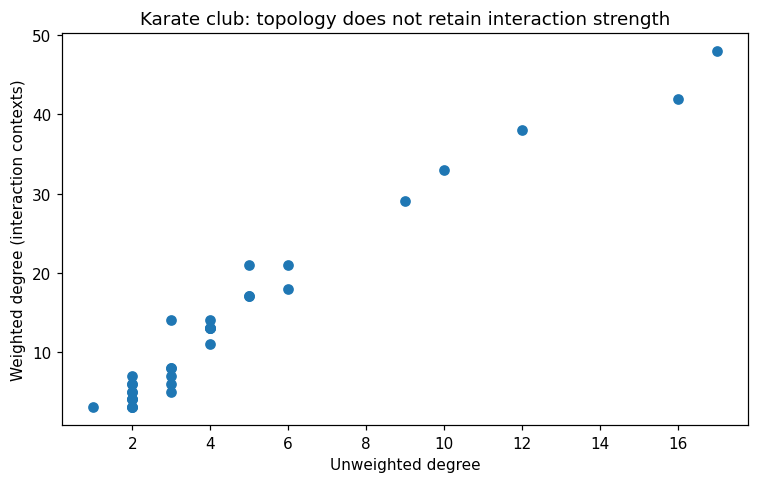

,graph,unweighted_Q,weighted_Q,strength_degree_spearman
0,Karate club,0.4188,0.4449,0.9483


In [23]:
r=raw_graphs['Karate club']; degrees=np.array([r.degree(v) for v in r]); strength=np.array([r.degree(v,weight='weight') for v in r])
fig,ax=plt.subplots(figsize=(7,4.5)); ax.scatter(degrees,strength); ax.set(xlabel='Unweighted degree',ylabel='Weighted degree (interaction contexts)',title='Karate club: topology does not retain interaction strength')
show_figure('weight_semantics','Weighted versus unweighted degree','Weights represent interaction contexts and are not interpreted as distances.')
q_unweighted=nx.community.modularity(r,nx.community.louvain_communities(r,weight=None,seed=SEED),weight=None); q_weighted=nx.community.modularity(r,nx.community.louvain_communities(r,weight='weight',seed=SEED),weight='weight')
display(save_table('weight_sensitivity',pd.DataFrame([{'graph':'Karate club','unweighted_Q':q_unweighted,'weighted_Q':q_weighted,'strength_degree_spearman':spearmanr(degrees,strength).statistic}])).round(4))

,view,n,m,triangles,density
0,Two-mode graph,32,89,0,0.179435
1,Women projection,18,139,631,0.908497


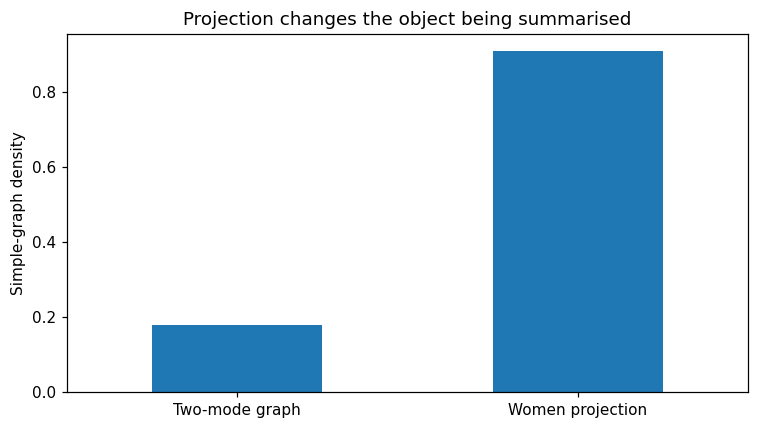

In [24]:
b=raw_graphs['Southern women']; women=[v for v,d in b.nodes(data=True) if d['bipartite']==0]; projection=nx.bipartite.weighted_projected_graph(b,women); pgraph,_,_=canonical_graph(projection); pdsc,_=describe_graph(pgraph)
projection_table=save_table('bipartite_projection',pd.DataFrame([{'view':'Two-mode graph','n':len(b),'m':b.number_of_edges(),'triangles':sum(nx.triangles(b).values())//3,'density':nx.density(b)},{'view':'Women projection','n':len(projection),'m':projection.number_of_edges(),'triangles':pdsc['triangles'],'density':pdsc['density']}]))
display(projection_table)
ax=projection_table.set_index('view')[['density']].plot.bar(figsize=(7,4),legend=False); ax.set(xlabel='',ylabel='Simple-graph density',title='Projection changes the object being summarised'); ax.tick_params(axis='x',rotation=0)
show_figure('bipartite_projection','Bipartite projection changes density','Pairwise ties through shared events do not give an equivalent rendering of the original two-mode graph.')

### Directionality in the neural archive

The directed case is deliberately not forced into an undirected interpretation. Repeated ordered pairs are combined by summing their value attributes. Reachability is evaluated on the directed simple graph and on its undirected projection. The plotting pipeline uses only the latter, so the directed results expose information it cannot convey. The archive is used as a network-encoding case, not as evidence about current neural function.

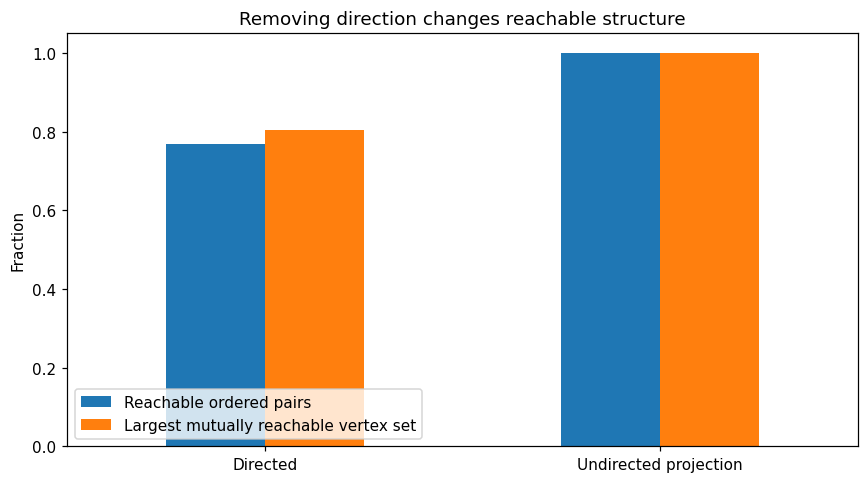

,representation,n,edges,reachable_pair_fraction,largest_mutually_reachable_fraction
0,Directed,297,2345,0.7695,0.8047
1,Undirected projection,297,2148,1.0000,1.0000


In [25]:
neural=raw_graphs['C. elegans']; dg=nx.DiGraph(); dg.add_nodes_from(neural.nodes)
for u,v,d in neural.edges(data=True):
    if u!=v: dg.add_edge(u,v,weight=dg.get_edge_data(u,v,{}).get('weight',0)+d.get('value',1))
ug=nx.Graph(dg); nr=len(dg); denominator=nr*(nr-1)
directed_reach=sum(len(nx.descendants(dg,v)) for v in dg)/denominator
undirected_reach=sum(len(nx.node_connected_component(ug,v))-1 for v in ug)/denominator
direction_table=save_table('direction_sensitivity',pd.DataFrame([
    {'representation':'Directed','n':nr,'edges':dg.number_of_edges(),'reachable_pair_fraction':directed_reach,'largest_mutually_reachable_fraction':max(map(len,nx.strongly_connected_components(dg)))/nr},
    {'representation':'Undirected projection','n':nr,'edges':ug.number_of_edges(),'reachable_pair_fraction':undirected_reach,'largest_mutually_reachable_fraction':max(map(len,nx.connected_components(ug)))/nr}]))
assert dg.number_of_edges()==2345 and ug.number_of_edges()==2148 and directed_reach<=undirected_reach
ax=direction_table.set_index('representation')[['reachable_pair_fraction','largest_mutually_reachable_fraction']].plot.bar(figsize=(8,4.5)); ax.set(xlabel='',ylabel='Fraction',ylim=(0,1.05),title='Removing direction changes reachable structure'); ax.tick_params(axis='x',rotation=0); ax.legend(['Reachable ordered pairs','Largest mutually reachable vertex set'],loc='lower left')
show_figure('directionality','Direction loss in the neural archive','Directed strong connectivity and undirected connectivity are different quantities; the summary is computed only after projection.')
display(direction_table.round(4))

In [26]:
check_rows=[]
for name,g in [('Empty',nx.Graph()),('One isolate',nx.empty_graph(1)),('Five isolates',nx.empty_graph(5)),('Complete',nx.complete_graph(7))]:
    structural_plot(g,name); ax=plt.gca(); check_rows.append({'case':name,'finite_track_coordinates':all(np.isfinite(line.get_xdata()).all() for line in ax.lines)}); plt.close()
structural_plot(worked,'Encoder check'); ax=plt.gca(); manual_degree_q=np.array([.3,1.5,2.,2.,2.7]); expected=np.log1p(manual_degree_q)/np.log(7)
assert np.allclose(ax.lines[0].get_xdata(),expected[[0,4]]) and np.allclose(ax.lines[1].get_xdata(),expected[[1,3]])
check_rows.append({'case':'Worked degree track','finite_track_coordinates':True}); plt.close()
encoder_checks=save_table('encoder_checks',pd.DataFrame(check_rows)); assert encoder_checks.finite_track_coordinates.all(); display(encoder_checks)

,case,finite_track_coordinates
0,Empty,True
1,One isolate,True
2,Five isolates,True
3,Complete,True
4,Worked degree track,True


## 5. Partition uncertainty

Repeated starts measure algorithmic variability. Adjusted Rand agreement is calculated between every pair of detected partitions, not against an assumed truth. Resolution sensitivity is separate: changing that parameter changes the objective itself.

In [27]:
partition_rows=[]; resolution_rows=[]
for name,g in graphs.items():
    parts=[]
    for seed in range(20):
        cs=nx.community.louvain_communities(g,weight=None,seed=seed); lab={v:i for i,c in enumerate(cs) for v in c}; parts.append([lab[v] for v in g])
    for i,j in itertools.combinations(range(20),2): partition_rows.append({'dataset':name,'seed_a':i,'seed_b':j,'ARI':adjusted_rand_score(parts[i],parts[j])})
    for gamma in [.5,.75,1,1.25,1.5,2]:
        for seed in range(5):
            cs=nx.community.louvain_communities(g,weight=None,resolution=gamma,seed=seed)
            resolution_rows.append({'dataset':name,'resolution':gamma,'seed':seed,'communities':len(cs),'Q_at_gamma':nx.community.modularity(g,cs,weight=None,resolution=gamma),'Q_at_one':nx.community.modularity(g,cs,weight=None,resolution=1)})
partition_stability=save_table('partition_stability',pd.DataFrame(partition_rows)); resolution=save_table('resolution_sensitivity',pd.DataFrame(resolution_rows))
display(partition_stability.groupby('dataset')['ARI'].agg(['median','min','max']).round(3))

,median,min,max
dataset,,,
C. elegans,0.577,0.412,0.801
Florentine families,1.000,0.759,1.000
Karate club,0.857,0.512,1.000
Les Miserables,0.834,0.580,1.000
Southern women,0.676,0.389,1.000


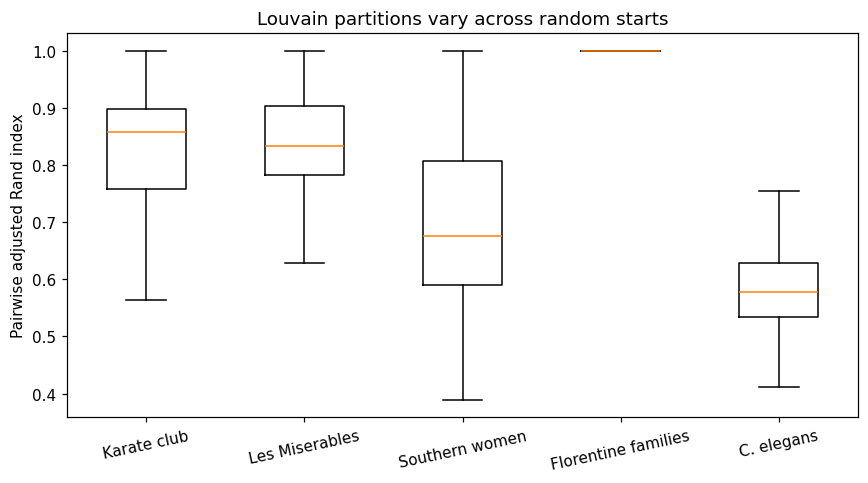

In [28]:
fig,ax=plt.subplots(figsize=(8,4.5)); ax.boxplot([partition_stability.loc[partition_stability.dataset==n,'ARI'] for n in graphs],tick_labels=list(graphs),showfliers=False); ax.tick_params(axis='x',rotation=12); ax.set(ylabel='Pairwise adjusted Rand index',title='Louvain partitions vary across random starts')
show_figure('partition_stability','Partition stability across random starts','Each distribution contains 190 dependent pairwise agreements from 20 starts.')

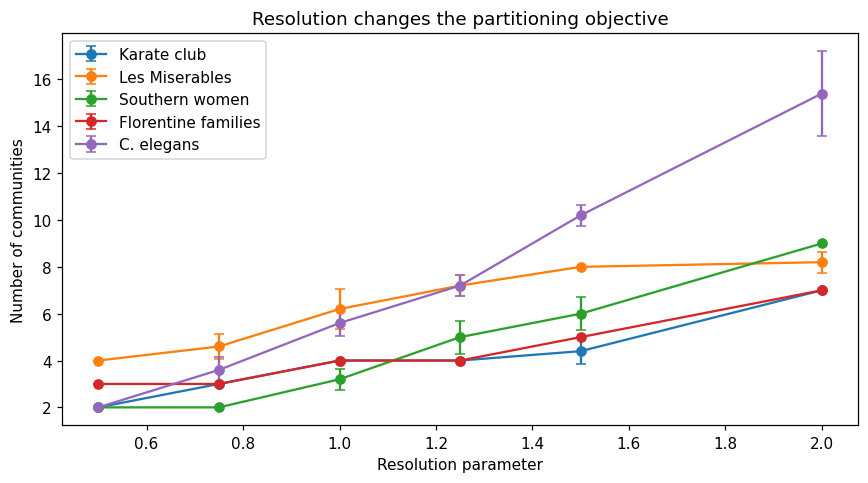

In [29]:
fig,ax=plt.subplots(figsize=(8,4.5))
for name in graphs:
    t=resolution[resolution.dataset==name].groupby('resolution')['communities'].agg(['mean','std']); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3,label=name)
ax.set(xlabel='Resolution parameter',ylabel='Number of communities',title='Resolution changes the partitioning objective'); ax.legend()
show_figure('resolution','Community-resolution sensitivity','Error bars are standard deviations across five optimisation seeds, not confidence intervals.')

## 6. Controlled graph ensembles

Five families are sampled at 120, 240 and 480 vertices, with twelve seeds per size. Erdős–Rényi and stochastic-block generators target mean degree eight. Preferential attachment adds four edges per new vertex; small-world graphs start at degree eight; geometric graphs use a radius derived from the same interior expected degree. Boundary effects mean that geometric graphs are not exactly degree matched. A degree-only classifier tests how much marginal degree information already separates the generators.

The full descriptor set excludes graph identifiers, vertex count, edge count, density and generator parameters. The experiment tests retention of generator-related signal, not discovery of mechanisms behind empirical networks.

Generator comparisons are sensitive to metrics and evaluation design (Thompson et al., 2022). Training-only imputation and held-out size evaluation avoid obvious information leakage (Kapoor and Narayanan, 2023).

In [30]:
def family_graph(family,n,seed):
    if family=='Random': return nx.fast_gnp_random_graph(n,8/(n-1),seed=seed)
    if family=='Preferential': return nx.barabasi_albert_graph(n,4,seed=seed)
    if family=='Small-world': return nx.watts_strogatz_graph(n,8,.08,seed=seed)
    if family=='Block':
        sizes=[n//4]*4; p_in=6/(sizes[0]-1); p_out=2/(n-sizes[0]); probs=[[p_in if i==j else p_out for j in range(4)] for i in range(4)]
        return nx.stochastic_block_model(sizes,probs,seed=seed)
    if family=='Geometric': return nx.random_geometric_graph(n,np.sqrt(8/(np.pi*n)),seed=seed)
    raise ValueError(family)
families=['Random','Preferential','Small-world','Block','Geometric']; ensemble_rows=[]
for family in families:
    for n in [120,240,480]:
        for seed in range(12):
            generation_seed=int(np.random.SeedSequence([SEED,families.index(family),n,seed,0]).generate_state(1)[0]); analysis_seed=int(np.random.SeedSequence([SEED,families.index(family),n,seed,1]).generate_state(1)[0]); g=family_graph(family,n,generation_seed); d,_=describe_graph(g,seed=analysis_seed,sample=32); d.update(family=family,size=n,seed=seed,generation_seed=generation_seed,analysis_seed=analysis_seed); ensemble_rows.append(d)
ensemble=save_table('graph_ensemble',pd.DataFrame(ensemble_rows))
display(ensemble.groupby(['family','size']).agg(graphs=('n','size'),mean_degree=('mean_degree','mean'),mean_clustering=('clustering_mean','mean'),mean_modularity=('modularity','mean')).round(3))

graphs  mean_degree  mean_clustering  mean_modularity
family       size                                                       
Block        120       12        8.026            0.129            0.486
             240       12        8.024            0.066            0.493
             480       12        8.006            0.031            0.470
Geometric    120       12        7.181            0.621            0.721
             240       12        7.308            0.617            0.811
             480       12        7.653            0.605            0.859
Preferential 120       12        7.733            0.161            0.292
             240       12        7.867            0.105            0.313
             480       12        7.933            0.060            0.316
Random       120       12        7.979            0.065            0.305
             240       12        7.996            0.033            0.321
             480       12        7.988            0.017            0.327
Small-world  120       12        8.000            0.512            0.661
             240       12        8.000            0.506            0.742
             480       12        8.000            0.508            0.796

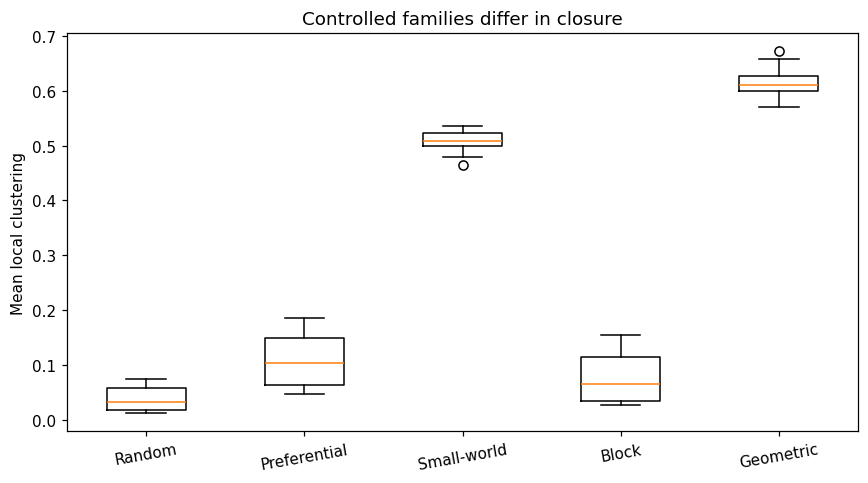

In [31]:
fig,ax=plt.subplots(figsize=(8,4.5)); ax.boxplot([ensemble.loc[ensemble.family==f,'clustering_mean'] for f in families],tick_labels=families); ax.set(ylabel='Mean local clustering',title='Controlled families differ in closure'); ax.tick_params(axis='x',rotation=10)
show_figure('family_clustering','Clustering across controlled families','Each family contributes 36 graphs; size and seed are retained for blocked evaluation.')

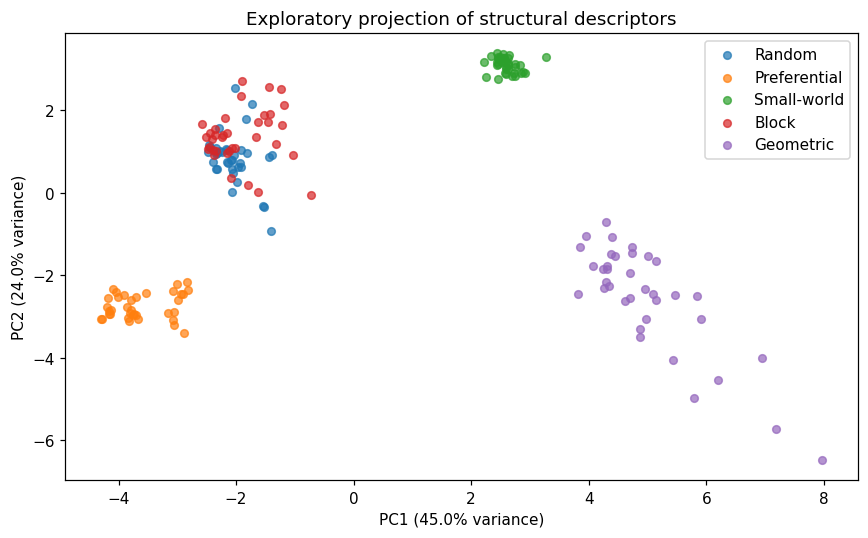

42

In [32]:
degree_features=['mean_degree','degree_cv','degree_gini','degree_q25','degree_q50','degree_q75','degree_q95']
shape_features=degree_features+['clustering_mean','clustering_q25','clustering_q50','clustering_q75','transitivity','largest_component_fraction','isolate_fraction','bridge_fraction','articulation_fraction','core_max','core_mean','modularity','largest_community_fraction','community_gini','assortativity','betweenness_mean','betweenness_q95']
visible_features=['degree_q25','degree_q50','degree_q75','clustering_q25','clustering_q50','clustering_q75','largest_community_fraction','bridge_fraction','articulation_fraction','isolate_fraction','betweenness_q95']
X=ensemble[shape_features]; y=ensemble.family
transform=make_pipeline(SimpleImputer(strategy='median'),StandardScaler(),PCA(n_components=2)); coords=transform.fit_transform(X); explained=transform[-1].explained_variance_ratio_
pca_table=save_table('pca_coordinates',pd.DataFrame({'family':y,'size':ensemble['size'],'seed':ensemble.seed,'PC1':coords[:,0],'PC2':coords[:,1]}))
fig,ax=plt.subplots(figsize=(8,5))
for family in families:
    t=pca_table[pca_table.family==family]; ax.scatter(t.PC1,t.PC2,label=family,s=25,alpha=.7)
ax.set(xlabel=f'PC1 ({explained[0]:.1%} variance)',ylabel=f'PC2 ({explained[1]:.1%} variance)',title='Exploratory projection of structural descriptors'); ax.legend()
show_figure('pca','Principal-component projection','This full-ensemble unsupervised projection is descriptive, not a held-out predictive result.')
(OUT/'pca_variance.json').write_text(json.dumps(explained.tolist()))

In [33]:
feature_sets={'Degree only':degree_features,'Visible subset':visible_features,'Full signature':shape_features}
def classifier(seed=SEED):
    return make_pipeline(SimpleImputer(strategy='median'),RandomForestClassifier(n_estimators=160,max_features='sqrt',min_samples_leaf=2,random_state=seed,n_jobs=1))
score_rows=[]; prediction_rows=[]
for label,features in feature_sets.items():
    for held_size in [120,240,480]:
        train=ensemble['size']!=held_size; test=~train; model=classifier(); model.fit(ensemble.loc[train,features],y[train]); pred=model.predict(ensemble.loc[test,features])
        score_rows.append({'feature_set':label,'held_size':held_size,'balanced_accuracy':balanced_accuracy_score(y[test],pred),'train_graphs':int(train.sum()),'test_graphs':int(test.sum())})
        for idx,p in zip(ensemble.index[test],pred): prediction_rows.append({'index':int(idx),'feature_set':label,'size':held_size,'seed':int(ensemble.loc[idx,'seed']),'true':y[idx],'predicted':p})
scores=save_table('size_holdout_scores',pd.DataFrame(score_rows)); predictions=save_table('size_holdout_predictions',pd.DataFrame(prediction_rows))
cv=StratifiedGroupKFold(n_splits=4,shuffle=True,random_state=SEED); pred_cv=cross_val_predict(classifier(),X,y,groups=ensemble.seed,cv=cv,n_jobs=1); cv_score=balanced_accuracy_score(y,pred_cv)
display(scores.round(3)); print(f'Seed-grouped cross-validation balanced accuracy: {cv_score:.4f}')
(OUT/'grouped_cv.json').write_text(json.dumps({'balanced_accuracy':cv_score,'folds':4,'groups':12}))

,feature_set,held_size,balanced_accuracy,train_graphs,test_graphs
0,Degree only,120,0.850,120,60
1,Degree only,240,0.833,120,60
2,Degree only,480,0.733,120,60
3,Visible subset,120,0.917,120,60
4,Visible subset,240,1.000,120,60
5,Visible subset,480,0.983,120,60
6,Full signature,120,0.950,120,60
7,Full signature,240,1.000,120,60
8,Full signature,480,0.983,120,60


Seed-grouped cross-validation balanced accuracy: 0.9944


67

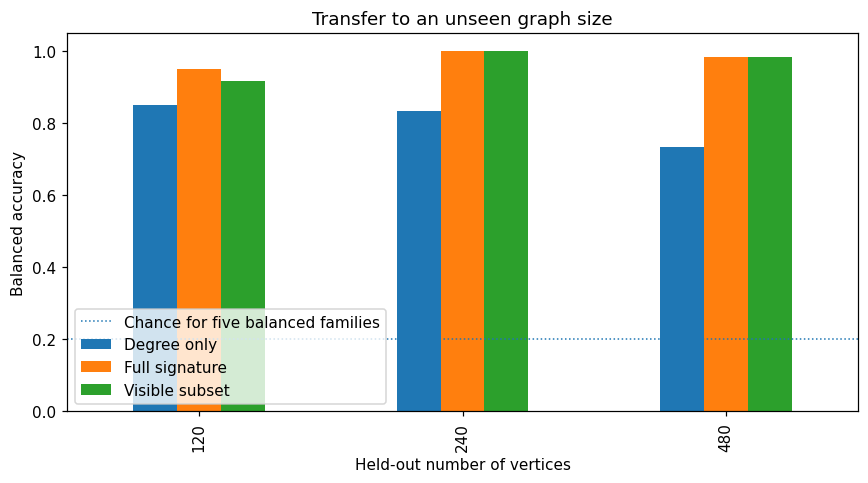

In [34]:
ax=scores.pivot(index='held_size',columns='feature_set',values='balanced_accuracy').plot.bar(figsize=(8,4.5)); ax.set(xlabel='Held-out number of vertices',ylabel='Balanced accuracy',ylim=(0,1.05),title='Transfer to an unseen graph size'); ax.axhline(.2,linestyle=':',linewidth=1,label='Chance for five balanced families'); ax.legend(loc='lower left')
show_figure('holdout_accuracy','Feature ablation with size holdout','All models use the same splits; imputation is fitted on training graphs only.')

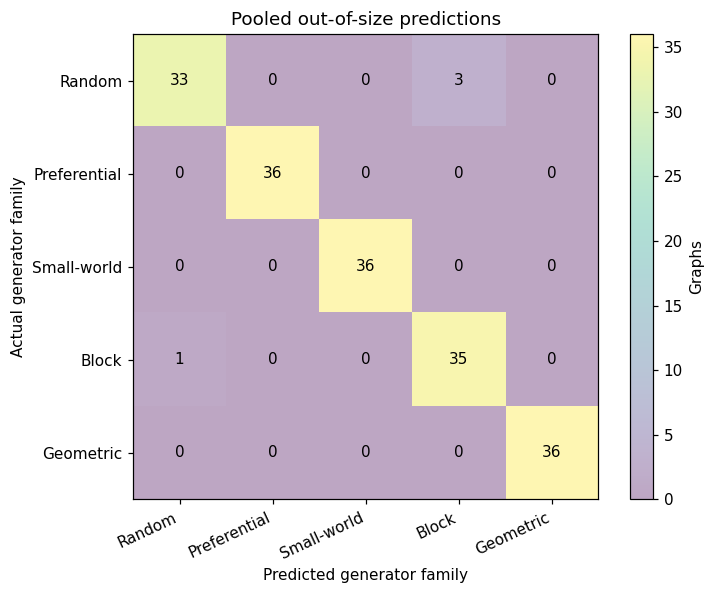

In [35]:
p=predictions[predictions.feature_set=='Full signature']; cm=confusion_matrix(p.true,p.predicted,labels=families)
save_table('confusion_matrix',pd.DataFrame(cm,index=families,columns=families).rename_axis('true').reset_index())
fig,ax=plt.subplots(figsize=(7,5.5)); im=ax.imshow(cm,alpha=.35); fig.colorbar(im,ax=ax,label='Graphs'); ax.set_xticks(range(5),families,rotation=25,ha='right'); ax.set_yticks(range(5),families); ax.set(xlabel='Predicted generator family',ylabel='Actual generator family',title='Pooled out-of-size predictions')
for i in range(5):
    for j in range(5): ax.text(j,i,str(cm[i,j]),ha='center',va='center')
show_figure('confusion','Out-of-size confusion matrix','Each of 180 graphs is predicted once by a model trained on the other two sizes.')

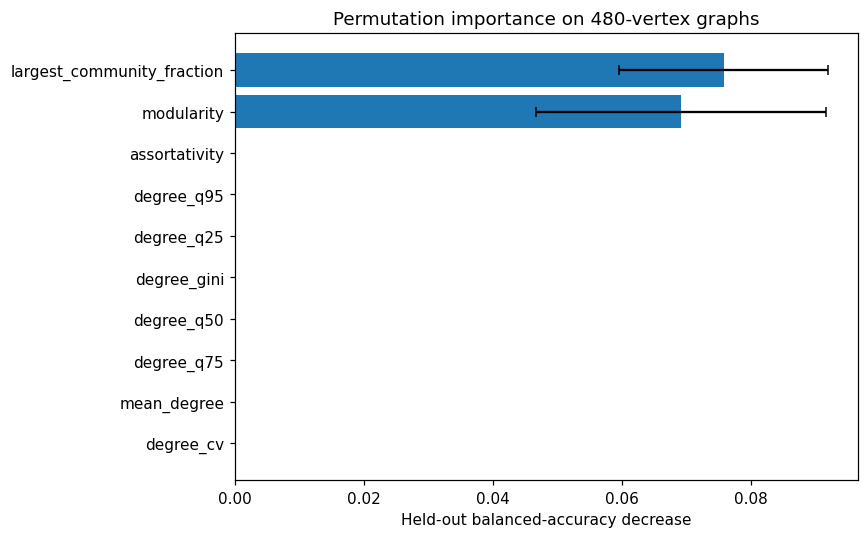

In [36]:
tr=ensemble['size']!=480; te=~tr; fitted=classifier(); fitted.fit(X[tr],y[tr]); importance=permutation_importance(fitted,X[te],y[te],scoring='balanced_accuracy',n_repeats=20,random_state=SEED,n_jobs=1)
imp=save_table('permutation_importance',pd.DataFrame({'feature':shape_features,'mean_drop':importance.importances_mean,'std_drop':importance.importances_std}).sort_values('mean_drop',ascending=False))
t=imp.head(10).sort_values('mean_drop'); fig,ax=plt.subplots(figsize=(8,5)); ax.barh(t.feature,t.mean_drop,xerr=t.std_drop,capsize=3); ax.set(xlabel='Held-out balanced-accuracy decrease',title='Permutation importance on 480-vertex graphs')
show_figure('importance','Held-out feature importance','Correlated descriptors may substitute for one another; this is not a causal mechanism ranking.')

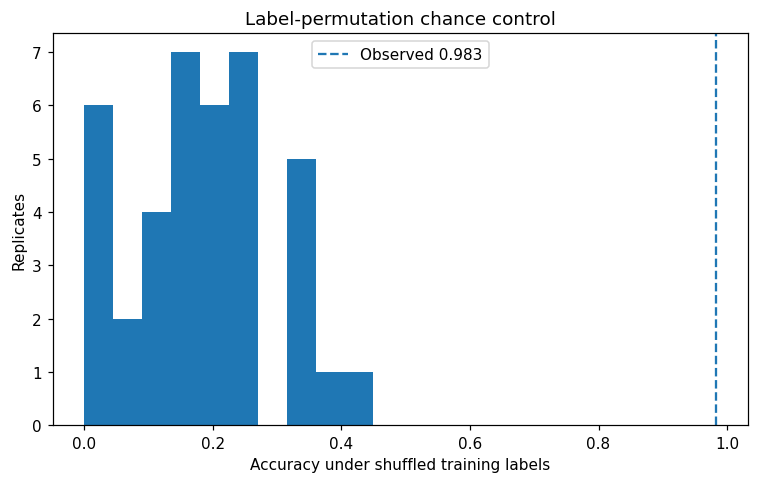

Observed 0.9833; plus-one permutation p-value 0.0250


In [37]:
null=[]; rng=np.random.default_rng(SEED)
for i in range(39):
    model=classifier(SEED+i); model.fit(X[tr],rng.permutation(y[tr])); null.append(balanced_accuracy_score(y[te],model.predict(X[te])))
observed=balanced_accuracy_score(y[te],fitted.predict(X[te])); p_perm=(1+sum(v>=observed for v in null))/(1+len(null)); save_table('permutation_null',pd.DataFrame({'replicate':range(39),'balanced_accuracy':null}))
fig,ax=plt.subplots(figsize=(7,4.5)); ax.hist(null,bins=10); ax.axvline(observed,linestyle='--',label=f'Observed {observed:.3f}'); ax.set(xlabel='Accuracy under shuffled training labels',ylabel='Replicates',title='Label-permutation chance control'); ax.legend()
show_figure('chance_control','Label-permutation chance control','Thirty-nine permutations give a minimum attainable plus-one p-value of 0.025; the diagnostic is exploratory.')
(OUT/'permutation_summary.json').write_text(json.dumps({'observed':observed,'permutations':39,'p_value':p_perm})); print(f'Observed {observed:.4f}; plus-one permutation p-value {p_perm:.4f}')

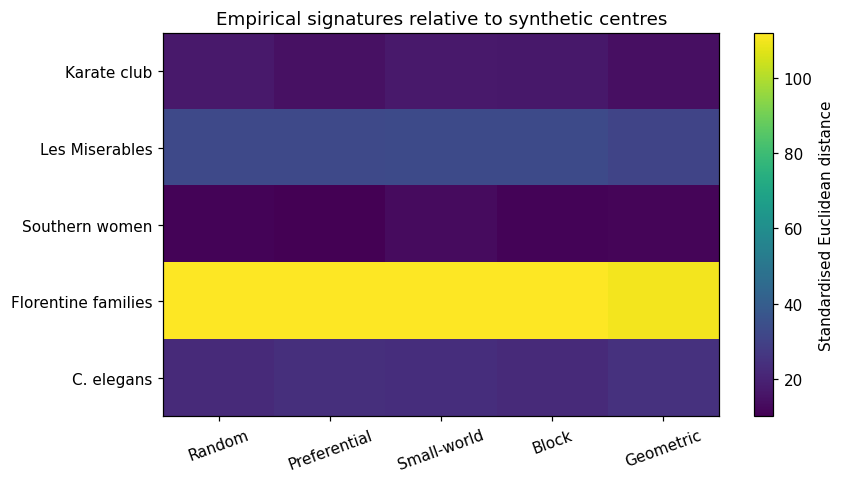

In [38]:
ref=make_pipeline(SimpleImputer(strategy='median'),StandardScaler()); ref.fit(X); query=pd.DataFrame(empirical).T[shape_features]; query_z=ref.transform(query); centres=[]
for f in families: centres.append(np.median(ref.transform(X[y==f]),axis=0))
dist=np.sqrt(((query_z[:,None,:]-np.array(centres)[None,:,:])**2).sum(axis=2)); save_table('empirical_family_distances',pd.DataFrame(dist,index=list(graphs),columns=families).rename_axis('dataset').reset_index())
fig,ax=plt.subplots(figsize=(8,4.5)); im=ax.imshow(dist,aspect='auto'); ax.set_yticks(range(len(graphs)),list(graphs)); ax.set_xticks(range(5),families,rotation=20); ax.set_title('Empirical signatures relative to synthetic centres'); fig.colorbar(im,ax=ax,label='Standardised Euclidean distance')
show_figure('retrieval','Distances from empirical signatures to generator centres','Synthetic scales define the metric; nearest centres do not identify empirical generating processes.')

## 7. Controlled structural changes

A rewiring sweep holds vertex and edge counts fixed while changing local closure. A block-model sweep varies expected external-neighbour share at fixed expected mean degree. Ten seeds replicate each setting. Planted-partition agreement is meaningful only for generated benchmarks; no equivalent ground-truth claim is made for empirical graphs.

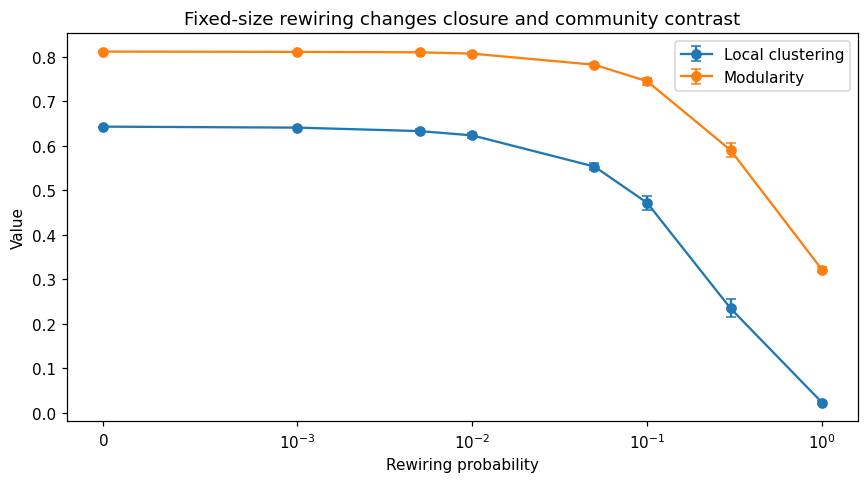

In [39]:
rewire_rows=[]
for beta in [0,.001,.005,.01,.05,.1,.3,1]:
    for seed in range(10):
        g=nx.watts_strogatz_graph(300,8,beta,seed=seed); d,_=describe_graph(g,seed=seed); rewire_rows.append(dict(beta=beta,seed=seed,**d))
rewiring=save_table('rewiring_sweep',pd.DataFrame(rewire_rows)); fig,ax=plt.subplots(figsize=(8,4.5))
for key,label in [('clustering_mean','Local clustering'),('modularity','Modularity')]:
    t=rewiring.groupby('beta')[key].agg(['mean','std']); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3,label=label)
ax.set_xscale('symlog',linthresh=.001); ax.set(xlabel='Rewiring probability',ylabel='Value',title='Fixed-size rewiring changes closure and community contrast'); ax.legend()
show_figure('rewiring','Small-world rewiring response','All graphs have 300 vertices and 1,200 edges; error bars are between-seed standard deviations.')

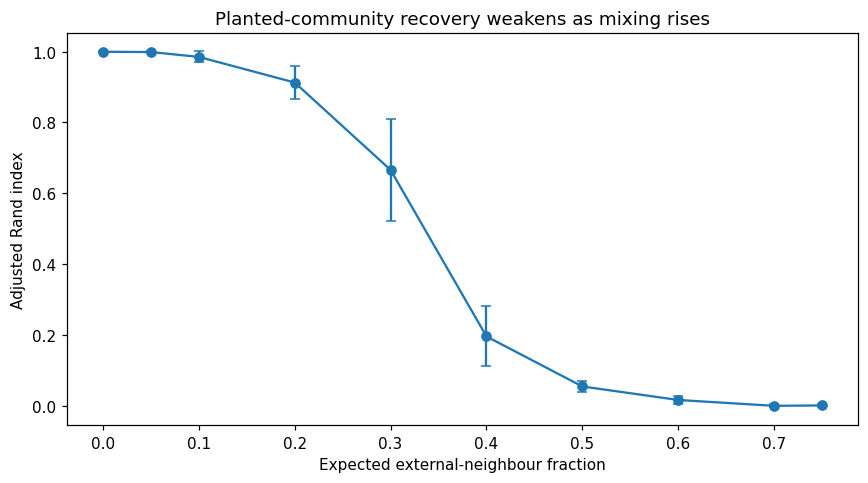

In [40]:
mix_rows=[]
for mu in [0,.05,.1,.2,.3,.4,.5,.6,.7,.75]:
    for seed in range(10):
        n=300; s=75; probs=[[8*(1-mu)/(s-1) if i==j else 8*mu/(n-s) for j in range(4)] for i in range(4)]
        g=nx.stochastic_block_model([s]*4,probs,seed=seed); d,z=describe_graph(g,seed=seed); lab={v:i for i,c in enumerate(z['communities']) for v in c}
        mix_rows.append(dict(mu=mu,seed=seed,ARI=adjusted_rand_score([v//s for v in g],[lab[v] for v in g]),**d))
mixing=save_table('block_mixing',pd.DataFrame(mix_rows)); t=mixing.groupby('mu')['ARI'].agg(['mean','std']); fig,ax=plt.subplots(figsize=(8,4.5)); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3); ax.set(xlabel='Expected external-neighbour fraction',ylabel='Adjusted Rand index',title='Planted-community recovery weakens as mixing rises')
show_figure('block_recovery','Planted-community recovery','Agreement uses the known block assignment, not a truth inferred from modularity.')

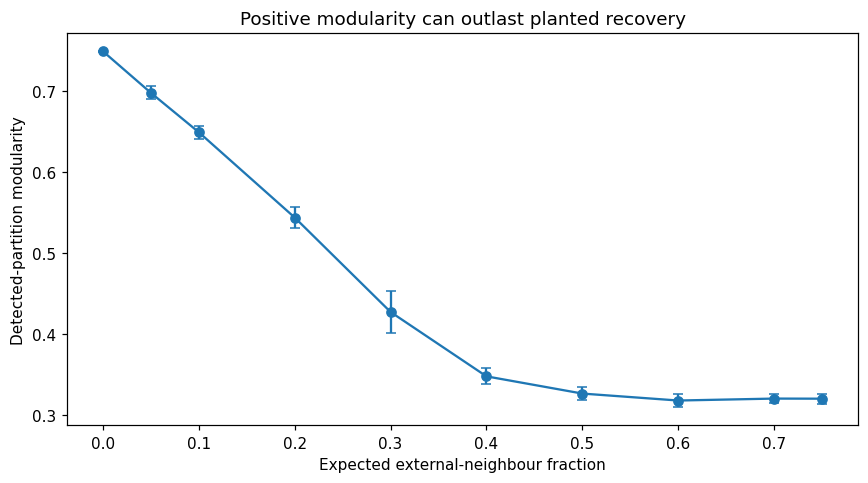

In [41]:
t=mixing.groupby('mu')['modularity'].agg(['mean','std']); fig,ax=plt.subplots(figsize=(8,4.5)); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3); ax.set(xlabel='Expected external-neighbour fraction',ylabel='Detected-partition modularity',title='Positive modularity can outlast planted recovery')
show_figure('block_modularity','Modularity under increasing mixing','Modularity and recovery answer different questions; a high score alone does not establish a true partition.')

,mu,status,attempts
0,0.1,generated,5
1,0.1,generation_failed,3
2,0.3,generated,6
3,0.3,generation_failed,2
4,0.5,generated,7
5,0.5,generation_failed,1
6,0.7,generated,8


,count,mean,std
mu,,,
0.1,5,0.998,0.004
0.3,6,0.731,0.049
0.5,7,0.052,0.024
0.7,8,0.004,0.012


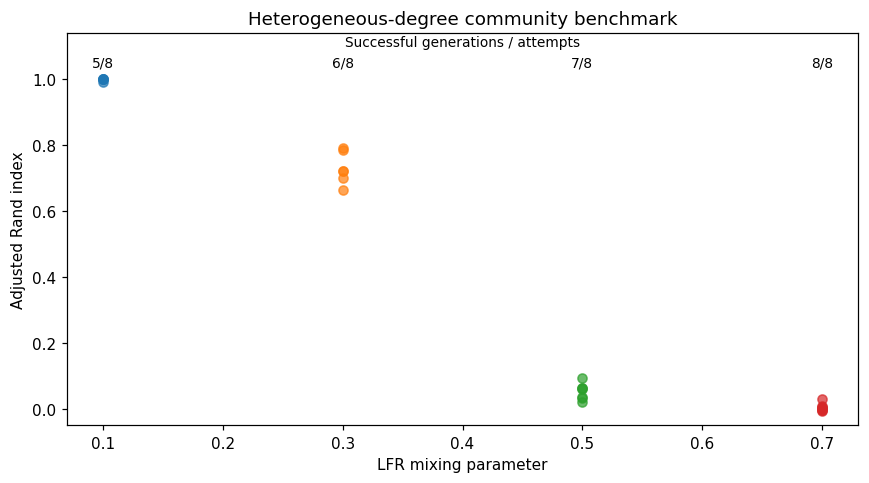

In [42]:
lfr_rows=[]
for mu in [.1,.3,.5,.7]:
    for seed in range(8):
        start=time.perf_counter()
        try:
            g=nx.LFR_benchmark_graph(250,3,1.5,mu,average_degree=8,min_community=15,max_community=60,seed=seed,max_iters=1000)
            sets={frozenset(g.nodes[v]['community']) for v in g}; truthmap={v:i for i,c in enumerate(sorted(sets,key=lambda x:min(x))) for v in c}; clean,mp,_=canonical_graph(g); d,z=describe_graph(clean,seed=seed); pred={v:i for i,c in enumerate(z['communities']) for v in c}
            score=adjusted_rand_score([truthmap[v] for v in g],[pred[mp[v]] for v in g]); lfr_rows.append(dict(mu=mu,seed=seed,status='generated',ARI=score,n=len(clean),m=clean.number_of_edges(),seconds=time.perf_counter()-start))
        except nx.ExceededMaxIterations:
            lfr_rows.append(dict(mu=mu,seed=seed,status='generation_failed',ARI=np.nan,n=250,m=np.nan,seconds=time.perf_counter()-start))
lfr=save_table('lfr_benchmark',pd.DataFrame(lfr_rows)); display(lfr.groupby(['mu','status']).size().rename('attempts').reset_index()); display(lfr.groupby('mu').ARI.agg(['count','mean','std']).round(3)); fig,ax=plt.subplots(figsize=(8,4.5))
for mu,group in lfr.groupby('mu'):
    valid=group.dropna(subset=['ARI']); ax.scatter(valid.mu,valid.ARI,alpha=.7); ax.text(mu,1.04,f'{len(valid)}/8',ha='center',fontsize=9)
ax.set(xlabel='LFR mixing parameter',ylabel='Adjusted Rand index',ylim=(-.05,1.14),title='Heterogeneous-degree community benchmark'); ax.text(.4,1.1,'Successful generations / attempts',ha='center',fontsize=9)
show_figure('lfr','LFR recovery and generation availability','Every attempt is retained; failed generations are not replaced with a different family.')

## 8. Perturbation, approximation and information loss

Edges are removed uniformly or preferentially from high-degree endpoints. Hub-biased deletion is a stress test, not an estimated real missingness process. Drift is measured in the standardised descriptor space fitted to the controlled ensemble. Baseline and perturbed partitions use a fixed optimisation seed, reducing but not eliminating stochastic differences.

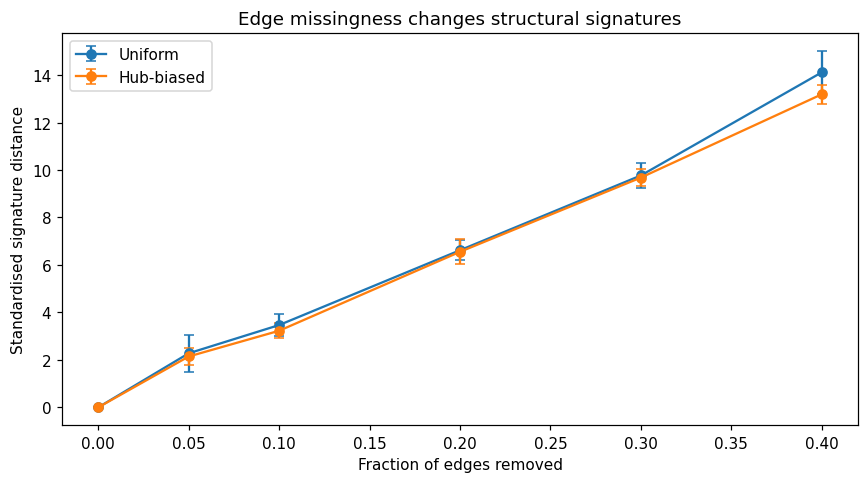

In [43]:
drop_rows=[]; base=family_graph('Block',300,3456); base_d,_=describe_graph(base); base_z=ref.transform(pd.DataFrame([base_d])[shape_features])[0]
for mechanism in ['Uniform','Hub-biased']:
    for fraction in [0,.05,.1,.2,.3,.4]:
        for seed in range(12):
            rng=np.random.default_rng(seed); h=base.copy(); edges=list(h.edges()); k=int(round(len(edges)*fraction)); weights=np.array([base.degree(u)+base.degree(v) for u,v in edges],dtype=float) if mechanism=='Hub-biased' else np.ones(len(edges)); chosen=rng.choice(len(edges),k,replace=False,p=weights/weights.sum()); h.remove_edges_from([edges[i] for i in chosen]); d,_=describe_graph(h); zz=ref.transform(pd.DataFrame([d])[shape_features])[0]
            drop_rows.append(dict(mechanism=mechanism,fraction=fraction,seed=seed,signature_distance=float(np.linalg.norm(zz-base_z)),**d))
dropout=save_table('edge_deletion',pd.DataFrame(drop_rows)); fig,ax=plt.subplots(figsize=(8,4.5))
for mech in ['Uniform','Hub-biased']:
    t=dropout[dropout.mechanism==mech].groupby('fraction').signature_distance.agg(['mean','std']); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3,label=mech)
ax.set(xlabel='Fraction of edges removed',ylabel='Standardised signature distance',title='Edge missingness changes structural signatures'); ax.legend()
show_figure('deletion_drift','Signature drift under edge deletion','Twelve deletion replicates per setting on one fixed graph; bars are standard deviations, not population uncertainty.')

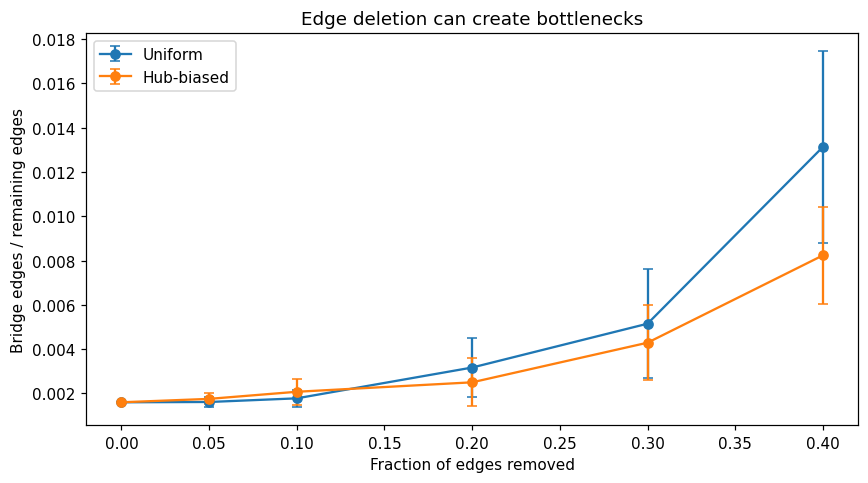

In [44]:
fig,ax=plt.subplots(figsize=(8,4.5))
for mech in ['Uniform','Hub-biased']:
    t=dropout[dropout.mechanism==mech].groupby('fraction').bridge_fraction.agg(['mean','std']); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3,label=mech)
ax.set(xlabel='Fraction of edges removed',ylabel='Bridge edges / remaining edges',title='Edge deletion can create bottlenecks'); ax.legend()
show_figure('deletion_bridges','Bottleneck sensitivity to missing edges','The denominator is remaining edges; both bridge counts and fractions are retained in the table.')

,MAE,max_error,spearman
sources,,,
4,0.00719,0.09267,0.57246
8,0.00576,0.05969,0.63182
16,0.00423,0.03404,0.69747
32,0.00294,0.01953,0.79619
64,0.00187,0.00973,0.89497
128,0.00109,0.00568,0.96059
240,0.00000,0.00000,1.00000


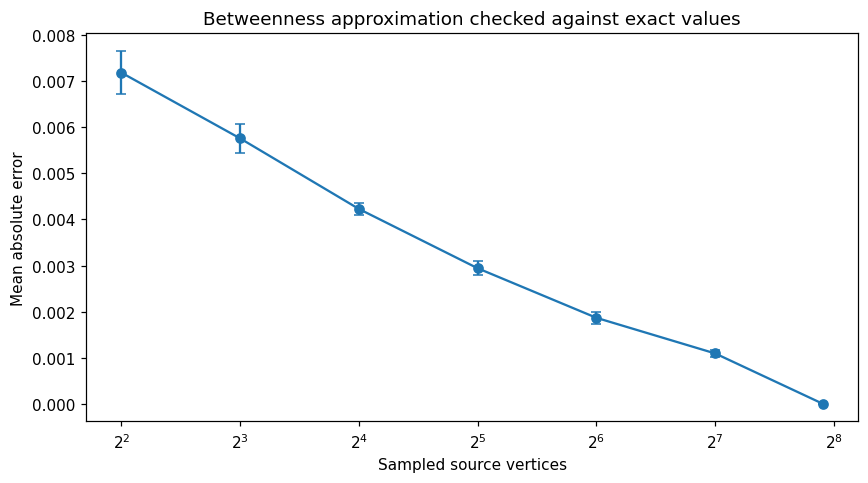

In [45]:
bw_rows=[]; bg=family_graph('Block',240,736); exact=np.array(list(nx.betweenness_centrality(bg,normalized=True,weight=None).values()))
for k in [4,8,16,32,64,128,240]:
    for seed in range(15):
        start=time.perf_counter(); estimated=np.array(list(nx.betweenness_centrality(bg,k=k,normalized=True,weight=None,seed=seed).values())); elapsed=time.perf_counter()-start
        bw_rows.append({'sources':k,'seed':seed,'MAE':float(np.abs(estimated-exact).mean()),'max_error':float(np.abs(estimated-exact).max()),'spearman':spearmanr(exact,estimated).statistic,'seconds':elapsed})
bw_results=save_table('betweenness_approximation',pd.DataFrame(bw_rows)); display(bw_results.groupby('sources')[['MAE','max_error','spearman']].mean().round(5)); t=bw_results.groupby('sources').MAE.agg(['mean','std']); fig,ax=plt.subplots(figsize=(8,4.5)); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3); ax.set_xscale('log',base=2); ax.set(xlabel='Sampled source vertices',ylabel='Mean absolute error',title='Betweenness approximation checked against exact values')
show_figure('betweenness_error','Sampling error in betweenness','Fifteen source samples per setting; the full-source calculation is compared with exact computation.')

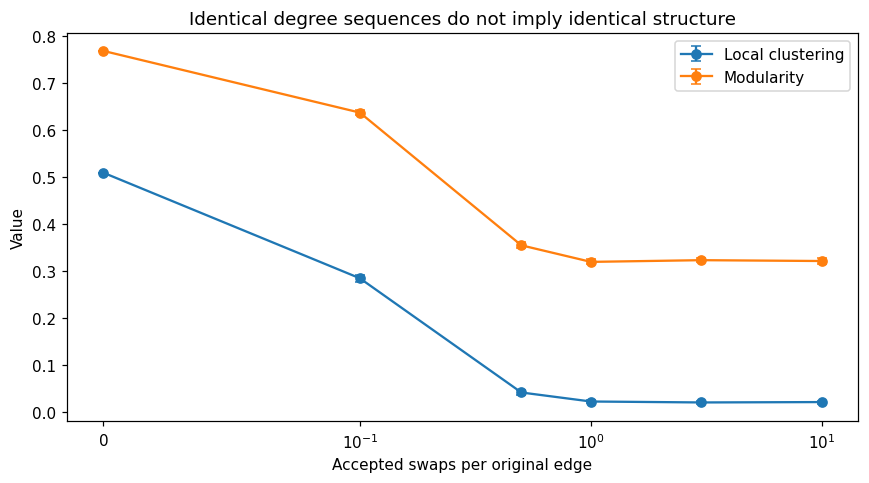

In [46]:
swap_rows=[]; g0=family_graph('Small-world',300,765); baseline,_=describe_graph(g0); degree0=sorted(dict(g0.degree()).values())
for factor in [0,.1,.5,1,3,10]:
    for seed in range(10):
        h=g0.copy(); nswaps=int(factor*h.number_of_edges())
        if nswaps: nx.double_edge_swap(h,nswap=nswaps,max_tries=50*nswaps,seed=seed)
        assert sorted(dict(h.degree()).values())==degree0
        d,_=describe_graph(h,seed=SEED); swap_rows.append(dict(swaps_per_edge=factor,seed=seed,**d))
swaps=save_table('degree_preserving_swaps',pd.DataFrame(swap_rows)); fig,ax=plt.subplots(figsize=(8,4.5))
for key,label in [('clustering_mean','Local clustering'),('modularity','Modularity')]:
    t=swaps.groupby('swaps_per_edge')[key].agg(['mean','std']); ax.errorbar(t.index,t['mean'],yerr=t['std'],marker='o',capsize=3,label=label)
ax.set_xscale('symlog',linthresh=.1); ax.set(xlabel='Accepted swaps per original edge',ylabel='Value',title='Identical degree sequences do not imply identical structure'); ax.legend()
show_figure('degree_preserving','Degree-preserving rewiring','Every degree sequence is checked for equality; closure and modularity remain free to change.')

,signature,unique_signatures,graphs_in_nonunique_groups,largest_collision_group,graphs
0,Degree sequence,492,964,20,1251
1,Degree + clustering,1146,190,6,1251
2,Degree + clustering + core + cuts,1170,154,3,1251


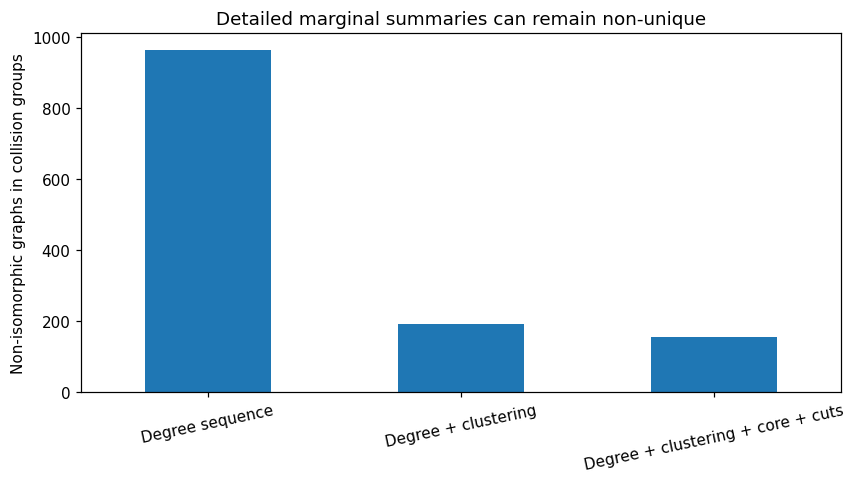

In [47]:
atlas_rows=[]
for idx,g in enumerate(nx.graph_atlas_g()):
    if len(g)<2: continue
    degrees=tuple(sorted(dict(g.degree()).values())); clusters=tuple(np.round(sorted(nx.clustering(g).values()),12)); core=tuple(sorted(nx.core_number(g).values()))
    atlas_rows.append({'atlas_id':idx,'n':len(g),'m':g.number_of_edges(),'degree_key':repr((len(g),degrees)),'closure_key':repr((len(g),degrees,clusters)),'extended_key':repr((len(g),degrees,clusters,core,len(list(nx.bridges(g))),nx.number_connected_components(g)))})
atlas=save_table('atlas_collision_keys',pd.DataFrame(atlas_rows)); coll=[]
for name,key in [('Degree sequence','degree_key'),('Degree + clustering','closure_key'),('Degree + clustering + core + cuts','extended_key')]:
    sizes=atlas.groupby(key).size(); coll.append({'signature':name,'unique_signatures':len(sizes),'graphs_in_nonunique_groups':int(sizes[sizes>1].sum()),'largest_collision_group':int(sizes.max()),'graphs':len(atlas)})
collisions=save_table('atlas_collisions',pd.DataFrame(coll)); display(collisions)
ax=collisions.set_index('signature')['graphs_in_nonunique_groups'].plot.bar(figsize=(8,4.5)); ax.set(xlabel='',ylabel='Non-isomorphic graphs in collision groups',title='Detailed marginal summaries can remain non-unique'); ax.tick_params(axis='x',rotation=12)
show_figure('collisions','Non-uniqueness in the graph atlas','The tested keys are numerical marginal summaries, not the complete visual grammar; the result exposes one information-loss mechanism.')

## 9. Computational scaling and representation cost

Extraction timing uses five generated sparse graphs per size. The full signature includes sampled betweenness: preprocessing is not constant time even when the plot contains a bounded set of marks. Peak traced Python allocation is measured separately from timing and does not include every native allocation. Dense adjacency storage is shown as a calculated reference, not a measured run.

Baseline timing includes all construction and raster rendering at a matched canvas size: descriptors for the summary; fifty layout iterations for node-link; dense matrix construction for adjacency. It is limited to 2,000 vertices and does not compare every possible graph-layout implementation.

A computational comparison is not a reader study (Filipov, Arleo and Miksch, 2023). The bootstrap below is conditional on the retained out-of-size predictions and does not refit models; shared training sets limit a frequentist coverage interpretation (Bates, Hastie and Tibshirani, 2024).

,median,min,max
n,,,
100,0.021,0.021,0.022
300,0.075,0.067,0.093
1000,0.379,0.301,0.441
3000,2.077,1.621,3.358
10000,9.511,7.751,14.138


,n,m,peak_traced_MiB,dense_float64_MiB
0,100,291,0.425,0.076
1,300,891,0.719,0.687
2,1000,2991,3.710,7.629
3,3000,8991,12.306,68.665
4,10000,29991,35.839,762.939


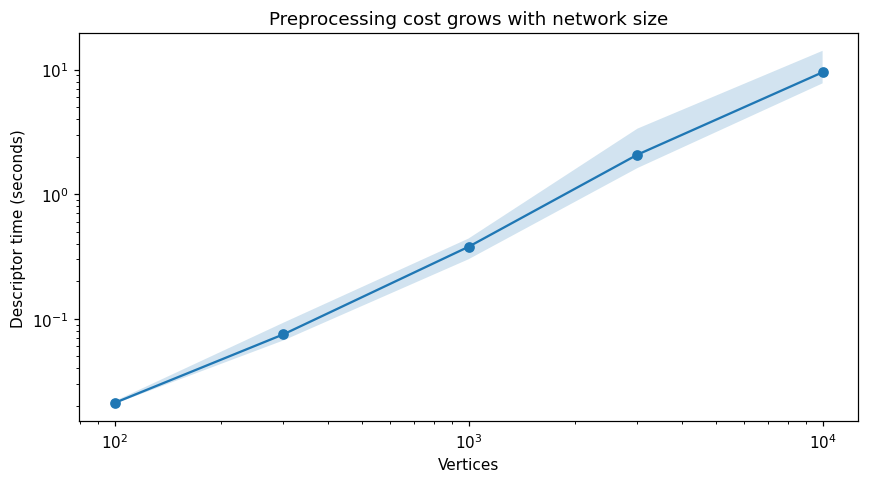

In [48]:
scale_rows=[]; memory_rows=[]
for n in [100,300,1000,3000,10000]:
    for seed in range(5):
        g=nx.barabasi_albert_graph(n,3,seed=seed); start=time.perf_counter(); d,_=describe_graph(g,seed=seed); elapsed=time.perf_counter()-start
        scale_rows.append({'n':n,'m':g.number_of_edges(),'seed':seed,'descriptor_seconds':elapsed})
    tracemalloc.start(); d,_=describe_graph(g); current,peak=tracemalloc.get_traced_memory(); tracemalloc.stop(); memory_rows.append({'n':n,'m':g.number_of_edges(),'peak_traced_MiB':peak/2**20,'dense_float64_MiB':n*n*8/2**20})
scaling=save_table('descriptor_scaling',pd.DataFrame(scale_rows)); memory=save_table('memory_scaling',pd.DataFrame(memory_rows)); display(scaling.groupby('n').descriptor_seconds.agg(['median','min','max']).round(3)); display(memory.round(3))
t=scaling.groupby('n').descriptor_seconds.agg(['median','min','max']); fig,ax=plt.subplots(figsize=(8,4.5)); ax.plot(t.index,t['median'],marker='o'); ax.fill_between(t.index,t['min'],t['max'],alpha=.2); ax.set_xscale('log'); ax.set_yscale('log'); ax.set(xlabel='Vertices',ylabel='Descriptor time (seconds)',title='Preprocessing cost grows with network size')
show_figure('runtime','Descriptor-extraction scaling','Median and range across five sparse preferential-attachment graphs per size; 32 betweenness source samples.')

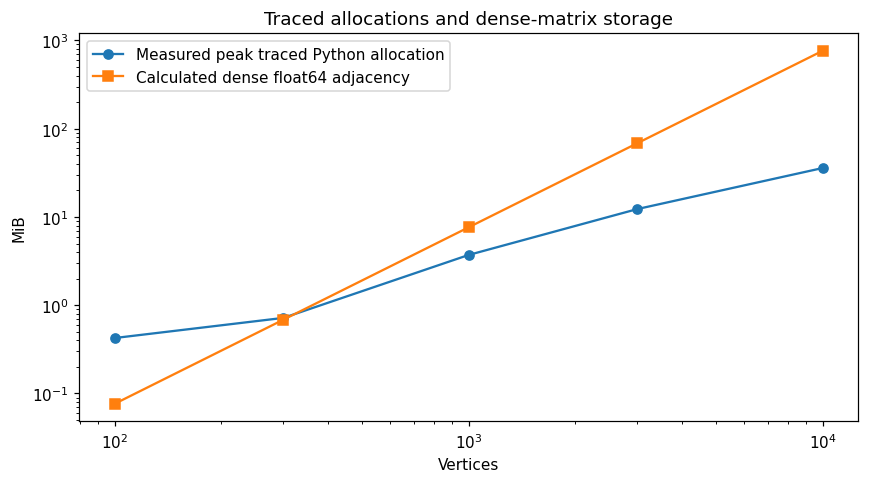

In [49]:
fig,ax=plt.subplots(figsize=(8,4.5)); ax.plot(memory.n,memory.peak_traced_MiB,marker='o',label='Measured peak traced Python allocation'); ax.plot(memory.n,memory.dense_float64_MiB,marker='s',label='Calculated dense float64 adjacency'); ax.set_xscale('log'); ax.set_yscale('log'); ax.set(xlabel='Vertices',ylabel='MiB',title='Traced allocations and dense-matrix storage'); ax.legend()
show_figure('memory','Memory scaling','The dense line is calculated storage, not a measured matrix run. Tracemalloc excludes some native allocations.')

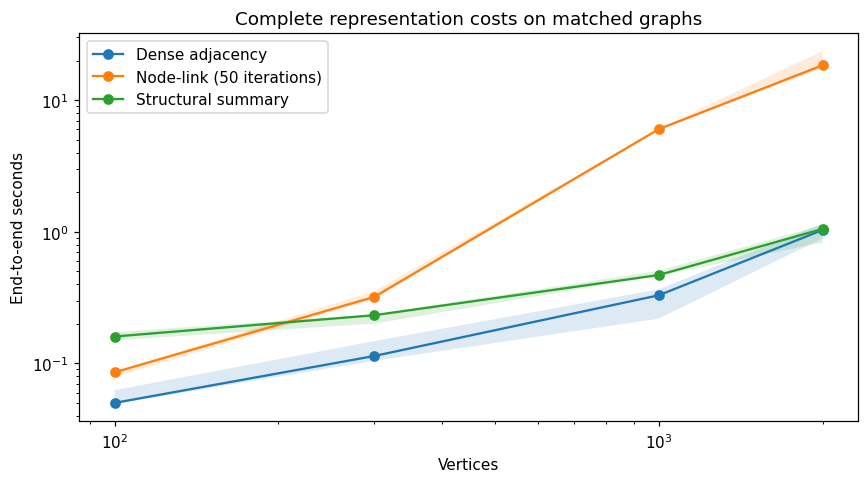

representation,Dense adjacency,Node-link (50 iterations),Structural summary
n,,,
100,0.050,0.086,0.160
300,0.114,0.320,0.233
1000,0.330,6.032,0.470
2000,1.033,18.457,1.053


In [50]:
baseline_rows=[]; f,aa=plt.subplots(); aa.plot([0,1]); f.canvas.draw(); plt.close(f)
for n in [100,300,1000,2000]:
    for seed in range(3):
        g=nx.barabasi_albert_graph(n,3,seed=seed)
        start=time.perf_counter(); structural_plot(g,'Timing'); plt.gcf().canvas.draw(); elapsed=time.perf_counter()-start; plt.close(); baseline_rows.append({'n':n,'seed':seed,'representation':'Structural summary','seconds':elapsed})
        start=time.perf_counter(); pos=nx.spring_layout(g,seed=seed,iterations=50,weight=None,method='force'); f,aa=plt.subplots(figsize=(9,5.6)); nx.draw_networkx(g,pos,ax=aa,node_size=3,with_labels=False,width=.2); f.canvas.draw(); elapsed=time.perf_counter()-start; plt.close(f); baseline_rows.append({'n':n,'seed':seed,'representation':'Node-link (50 iterations)','seconds':elapsed})
        start=time.perf_counter(); A=nx.to_numpy_array(g,weight=None); f,aa=plt.subplots(figsize=(9,5.6)); aa.imshow(A,interpolation='nearest'); f.canvas.draw(); elapsed=time.perf_counter()-start; plt.close(f); baseline_rows.append({'n':n,'seed':seed,'representation':'Dense adjacency','seconds':elapsed})
baseline_times=save_table('baseline_times',pd.DataFrame(baseline_rows)); fig,ax=plt.subplots(figsize=(8,4.5))
for name,t in baseline_times.groupby('representation'):
    s=t.groupby('n').seconds.agg(['median','min','max']); ax.plot(s.index,s['median'],marker='o',label=name); ax.fill_between(s.index,s['min'],s['max'],alpha=.15)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set(xlabel='Vertices',ylabel='End-to-end seconds',title='Complete representation costs on matched graphs'); ax.legend()
show_figure('baseline_times','End-to-end baseline timings','Construction and rendering at the same canvas size; three graphs per size, without a perceptual outcome.')
display(baseline_times.groupby(['n','representation']).seconds.median().unstack().round(3))

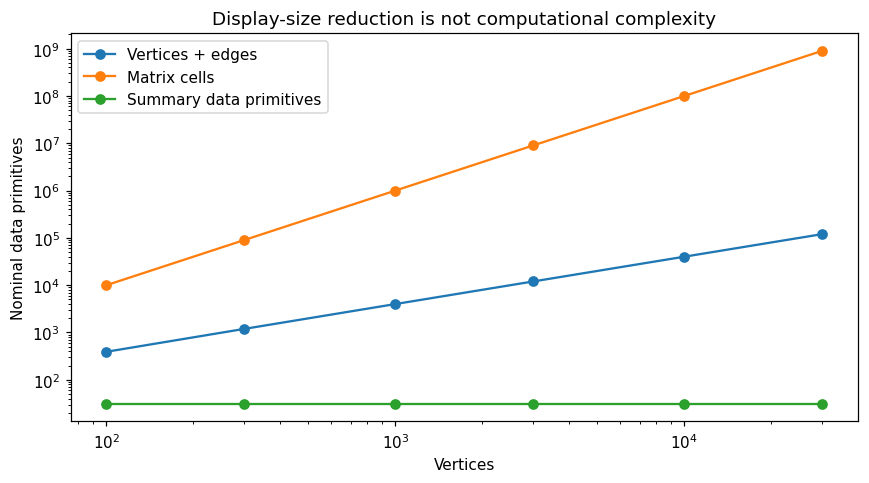

In [51]:
n=np.array([100,300,1000,3000,10000,30000]); m=3*n-9; complexity=pd.DataFrame({'n':n,'sparse_node_link_marks':n+m,'dense_matrix_cells':n*n,'summary_max_primitives':np.full(len(n),4*3+13+3*2)}); save_table('representation_complexity',complexity)
fig,ax=plt.subplots(figsize=(8,4.5))
for col,label in [('sparse_node_link_marks','Vertices + edges'),('dense_matrix_cells','Matrix cells'),('summary_max_primitives','Summary data primitives')]: ax.plot(n,complexity[col],marker='o',label=label)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set(xlabel='Vertices',ylabel='Nominal data primitives',title='Display-size reduction is not computational complexity'); ax.legend()
show_figure('mark_complexity','Representation mark complexity','Counts exclude axes, text and raster pixels. Twelve community blocks and one residual block bound the strip.')

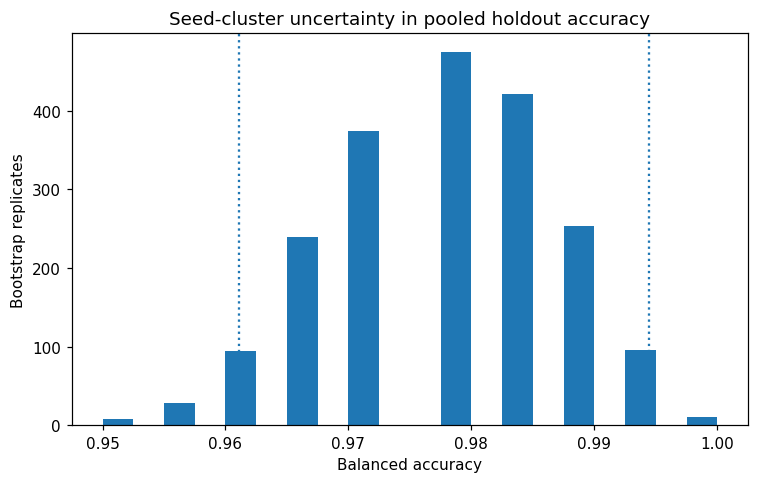

,ensemble_graphs,empirical_graphs,numerical_checks,numerical_checks_passed,max_scaling_vertices,size_holdout_balanced_accuracy,bootstrap_replicates,label_permutation_p,lfr_attempts,lfr_successes,human_participants
0,180,5,103,103,10000,0.977778,2000,0.025,32,26,0


Pooled balanced accuracy 0.9778, seed-cluster 95% interval [0.9611, 0.9944].


In [52]:
p=predictions[predictions.feature_set=='Full signature']; rng=np.random.default_rng(SEED); boot=[]
for rep in range(2000):
    seeds=rng.choice(np.arange(12),12,replace=True); b=pd.concat([p[p.seed==s] for s in seeds],ignore_index=True); boot.append(balanced_accuracy_score(b.true,b.predicted))
ci=np.quantile(boot,[.025,.975]); accuracy=balanced_accuracy_score(p.true,p.predicted)
summary={'ensemble_graphs':len(ensemble),'empirical_graphs':len(graphs),'numerical_checks':len(tests),'numerical_checks_passed':int(tests.passed.sum()),'max_scaling_vertices':int(scaling.n.max()),'size_holdout_balanced_accuracy':accuracy,'seed_cluster_bootstrap_95CI':ci.tolist(),'bootstrap_replicates':2000,'pca_variance':explained.tolist(),'label_permutation_p':p_perm,'lfr_attempts':len(lfr),'lfr_successes':int((lfr.status=='generated').sum()),'human_participants':0}
(OUT/'study_summary.json').write_text(json.dumps(summary,indent=2)); fig,ax=plt.subplots(figsize=(7,4.5)); ax.hist(boot,bins=20); ax.axvline(ci[0],linestyle=':'); ax.axvline(ci[1],linestyle=':'); ax.set(xlabel='Balanced accuracy',ylabel='Bootstrap replicates',title='Seed-cluster uncertainty in pooled holdout accuracy')
show_figure('bootstrap','Uncertainty in generator discrimination','The bootstrap resamples twelve seed clusters; it does not quantify transfer to real networks.')
display(pd.DataFrame([summary]).drop(columns=['pca_variance','seed_cluster_bootstrap_95CI'])); print(f'Pooled balanced accuracy {accuracy:.4f}, seed-cluster 95% interval [{ci[0]:.4f}, {ci[1]:.4f}].')

## 10. Findings and boundaries

The experiments establish a working structural summary and reproducible computational tests. Closed-form checks concern numerical correctness. Generator classification concerns retained descriptor information. Perturbations concern specified transformations. Timings concern these implementations and graph families. None substitutes for a human-subjects readability comparison.

The case studies are small and selected for interpretability. Social, historical, literary and bipartite meanings differ. Neither a shared descriptor nor proximity to a synthetic family proves a shared real-world mechanism. Atlas collisions warn against uniqueness claims. The overview is a route into detailed inspection, not a replacement for edge-level evidence.

The full-signature pooled balanced accuracy is 97.78%, compared with 80.56% for degree alone and 96.67% for the visible subset. Four full-signature errors confuse random and planted-block graphs. At mixing 0.70, mean planted recovery is about 0.001 while mean modularity remains about 0.321. These outcomes support a restricted descriptive contribution, not a universal visual advantage. Numerical equality does not entail a unique graph or equivalent drawing (van Wageningen, Mchedlidze and Telea, 2025).

In [53]:
objective_evidence=pd.DataFrame([
 {'objective':'Build the corpus','evidence':'datasets.json; data_cleaning.csv; graph_ensemble.csv','status':'Five complete small case graphs and 180 controlled graphs; large-graph tests are synthetic'},
 {'objective':'Compute descriptors','evidence':'empirical_descriptors.csv; numerical_tests.csv','status':f'{len(tests)} numerical checks; approximation error reported'},
 {'objective':'Implement the plot','evidence':'Worked and empirical structural plots','status':'Percentile tracks, community share and bottleneck markers implemented'},
 {'objective':'Compare representations','evidence':'baseline_times.csv; size_holdout_scores.csv','status':'Computational and descriptor comparisons; human readability unmeasured'},
 {'objective':'Identify limitations','evidence':'atlas_collisions.csv; edge_deletion.csv; lfr_benchmark.csv','status':'Information loss, sensitivity and generation failure retained'}]); save_table('objective_evidence',objective_evidence); display(objective_evidence)
summary=json.loads((OUT/'study_summary.json').read_text()); summary['analytical_figures']=len(figures); (OUT/'study_summary.json').write_text(json.dumps(summary,indent=2)); print(f'{len(figures)} numbered analytical figures saved and embedded.')

,objective,evidence,status
0,Build the corpus,datasets.json; data_cleaning.csv; graph_ensemb...,Five complete small case graphs and 180 contro...
1,Compute descriptors,empirical_descriptors.csv; numerical_tests.csv,103 numerical checks; approximation error repo...
2,Implement the plot,Worked and empirical structural plots,"Percentile tracks, community share and bottlen..."
3,Compare representations,baseline_times.csv; size_holdout_scores.csv,Computational and descriptor comparisons; huma...
4,Identify limitations,atlas_collisions.csv; edge_deletion.csv; lfr_b...,"Information loss, sensitivity and generation f..."


42 numbered analytical figures saved and embedded.


## 11. Rare structural roles outside the percentile bands

Consider two complete graphs of fifty vertices joined by one edge. The construction has 100 vertices and 2,451 edges. Ninety-eight degrees equal 49 and two equal 50. The two bridge endpoints are the only vertices with non-zero betweenness. Consequently, all five reported betweenness percentiles are zero and all five degree percentiles are 49. Removing the one bridge nevertheless separates two equally sized components.

This is an analytic counterexample to treating percentile tracks as a complete account of structural importance. It is not a collision for the complete structural plot: its bridge and articulation tracks retain non-zero values. The example motivates inspection of the identities and component masses behind a low bridge fraction.

In [54]:
tail=nx.disjoint_union(nx.complete_graph(50),nx.complete_graph(50)); tail.add_edge(49,50)
tail_degree=np.array([d for _,d in tail.degree()]); tail_bw=np.array(list(nx.betweenness_centrality(tail,normalized=True).values()))
tail_clustering=np.array(list(nx.clustering(tail).values()))
tail_bridges=list(nx.bridges(tail)); tail_articulations=list(nx.articulation_points(tail))
assert tail.number_of_nodes()==100
assert tail.number_of_edges()==2451
assert len(tail_bridges)==1 and len(tail_articulations)==2
assert np.all(np.quantile(tail_degree,[.05,.25,.5,.75,.95])==49)
assert np.all(np.quantile(tail_bw,[.05,.25,.5,.75,.95])==0)
cut=tail.copy();cut.remove_edge(49,50)
assert sorted(map(len,nx.connected_components(cut)))==[50,50]
tail_results=save_table('tail_counterexample',pd.DataFrame([
 {'quantity':'Vertices','value':len(tail)},
 {'quantity':'Edges','value':tail.number_of_edges()},
 {'quantity':'Bridges','value':len(tail_bridges)},
 {'quantity':'Articulations','value':len(tail_articulations)},
 {'quantity':'Bridge fraction','value':len(tail_bridges)/tail.number_of_edges()},
 {'quantity':'Degree 95th percentile','value':float(np.quantile(tail_degree,.95))},
 {'quantity':'Betweenness 95th percentile','value':float(np.quantile(tail_bw,.95))},
 {'quantity':'Maximum betweenness','value':float(tail_bw.max())},
 {'quantity':'Largest component fraction after bridge removal','value':max(map(len,nx.connected_components(cut)))/len(tail)}]))
display(tail_results)
summary=json.loads((OUT/'study_summary.json').read_text()); summary['analytic_tail_checks']=6
(OUT/'study_summary.json').write_text(json.dumps(summary,indent=2))

,quantity,value
0,Vertices,100.000000
1,Edges,2451.000000
2,Bridges,1.000000
3,Articulations,2.000000
4,Bridge fraction,0.000408
5,Degree 95th percentile,49.000000
6,Betweenness 95th percentile,0.000000
7,Maximum betweenness,0.505051
8,Largest component fraction after bridge removal,0.500000


556

## References and source documentation

Abdelaal, M. et al. (2024) ‘STEP: Sequence of time-aligned edge plots’, *Information Visualization*, 23(4), pp. 328–346. doi:10.1177/14738716241265111.

Bates, S., Hastie, T. and Tibshirani, R. (2024) ‘Cross-Validation: What Does It Estimate and How Well Does It Do It?’, *Journal of the American Statistical Association*, 119(546), pp. 1434–1445. doi:10.1080/01621459.2023.2197686.

Di Bartolomeo, S. et al. (2024) ‘Evaluating graph layout algorithms: A systematic review of methods and best practices’, *Computer Graphics Forum*, 43(6), e15073. doi:10.1111/cgf.15073.

Filipov, V., Arleo, A. and Miksch, S. (2023) ‘Are We There Yet? A Roadmap of Network Visualization from Surveys to Task Taxonomies’, *Computer Graphics Forum*, 42(6), e14794. doi:10.1111/cgf.14794.

Kapoor, S. and Narayanan, A. (2023) ‘Leakage and the reproducibility crisis in machine-learning-based science’, *Patterns*, 4(9), 100804. doi:10.1016/j.patter.2023.100804.

Kunegis, J. et al. (2023) ‘SynGraphy: Succinct Summarisation of Large Networks via Small Synthetic Representative Graphs’, *arXiv*, 2302.07755. doi:10.48550/arXiv.2302.07755.

NetworkX Developers (2025) *NetworkX 3.6.1 documentation*. https://networkx.org/documentation/stable/. Specific source dataset pages and the archived igraph file are identified in `data/datasets.json`.

Peixoto, T.P. (2023) *Descriptive vs. Inferential Community Detection in Networks: Pitfalls, Myths and Half-Truths*. Cambridge University Press. doi:10.1017/9781009118897.

Samuel, S. and Mietchen, D. (2024) ‘Computational reproducibility of Jupyter notebooks from biomedical publications’, *GigaScience*, 13, giad113. doi:10.1093/gigascience/giad113.

Thompson, R. et al. (2022) ‘On Evaluation Metrics for Graph Generative Models’, *arXiv*, 2201.09871. doi:10.48550/arXiv.2201.09871.

van Wageningen, S., Mchedlidze, T. and Telea, A.C. (2025) ‘Same Quality Metrics, Different Graph Drawings’, *LIPIcs*, 357, pp. 7:1–7:13. doi:10.4230/LIPIcs.GD.2025.7.

All numeric results and analytical figures above arise from the executed code. External studies motivate the methods and their interpretation; they are not the sources of the reported experimental values.